# TCR data exploration

Here some basic manual exploration of the TCR data is done.

## Data structure:

**Sequence Information:**
- *nSeqFR1-4, nSeqCDR1-3:* Nucleotide sequences of Framework Regions (FR) and Complementarity Determining Regions (CDR)
- *aaSeqFR1-4, aaSeqCDR1-3:* Amino acid sequences of the same regions
- *targetSequences:* The full target sequence

**Clone Metrics:**
- *cloneId:* Unique identifier for each clone
- *readCount:* Number of reads supporting this clone
- *uniqueMoleculeCount:* Number of unique molecules (UMIs)

**V(D)J Gene Usage:**
- *allVHitsWithScore:* Which V genes were used
- *allDHitsWithScore:* Which D genes were used
- *allJHitsWithScore:* Which J genes were used

**Quality Metrics**
- *minQualFR1-4, minQualCDR1-3:* Quality scores for each region

In [1]:
setwd("/scratch_isilon/groups/singlecell/shared/projects/covid-pascual-reguant")

## Libraries

In [2]:
library(glue)
library(here)
library(tidyverse)
library(tidytext)
library(Biostrings)
library(patchwork)
library(ggalluvial)
library(ggh4x)
library(viridis)

here() starts at /scratch_isilon/groups/singlecell/shared/projects/covid-pascual-reguant

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: BiocGenerics

Loading required package: generics


Attaching package: ‘generics’


The following object is masked from ‘package:lubridate’:

    as.difftime


The following object is masked from ‘package:dplyr’:

    explain


The following objects are masked from ‘package:base’:

    as.difftime, as.factor, as.ordered, intersect, is.element, setdiff,
    se

## Parameters

In [3]:
source(here::here("misc/paths.R"))

Rows: 20 Columns: 17
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (17): donor_id, study_id, disease_group, sex, age, sars-cov-2_antemortem...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


## Load data

In [4]:
tcr_df <- "{tcr_sp}/tcrs-meb.tsv" %>%
    glue() %>%
    here() %>%
    readr::read_tsv(file = .) %>% 
    data.frame()

tcr_df <- tcr_df %>%
    dplyr::rename(cond_tissue = study_id_tissue) %>%
    mutate(tissue = case_when(str_detect(tolower(cond_tissue), "lung") ~ "lung",
                              str_detect(tolower(cond_tissue), "lymph-node") ~ "lymph-node",
                              TRUE ~ "unknown"),
           condition = case_when(str_detect(tolower(cond_tissue), "control") ~ "control",
                                 str_detect(tolower(cond_tissue), "acute") ~ "acute",
                                 str_detect(tolower(cond_tissue), "chronic") ~ "chronic",
                                 str_detect(tolower(cond_tissue), "prolonged") ~ "prolonged",
                                 TRUE ~ "unknown"),
           chain = case_when(str_detect(allVHitsWithScore, "TRAV") ~ "TRA",
                             str_detect(allVHitsWithScore, "TRBV") ~ "TRB",
                             TRUE ~ "unknown"),
           cdr3_length = nchar(as.character(aaSeqCDR3)))  %>%
    filter(cond_tissue != "chronic_case_4-lung")

head(tcr_df)

Rows: 1345 Columns: 42
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (30): tagValueCELL, targetSequences, targetQualities, allVHitsWithScore,...
dbl (10): cloneId, readCount, uniqueMoleculeCount, minQualFR1, minQualCDR1, ...
lgl  (2): allCHitsWithScore, allCAlignments

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


,cloneId,tagValueCELL,readCount,uniqueMoleculeCount,targetSequences,targetQualities,allVHitsWithScore,allDHitsWithScore,allJHitsWithScore,allCHitsWithScore,⋯,orig,cond_tissue,nSeq_full,aaSeq_full,bc,cloneID2,tissue,condition,chain,cdr3_length
,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<lgl>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>
1,0,CGCCTCCCTCCTCTAT,147582,10,"GCCTCATTCCTGCTGTGATCCTGCCATGGATACCTGGCTCGTATGCTGGGCAATTTTTAGTCTCTTGAAAGCAGGACTCACAGAACCTGA,CACCCAGACTCCCAGACATCAGGTCTCACAGATGGGACAGGAAGTGATCTTGCGCTGTGTCCCCATCTCTAATCACTTATACTTCTATTGGTACAGACAAATCTTGGGGCAGAAAGTCGAG,CGTTCCAANGCAGTGNNGTATCAACGCAGAGTACATGGGAAATTCTCAGTTGAAAGGCCTGATGGATCAAATTTCACTCTGAAGATCCGGTCCACAAAGCTGGAGGACTCAGCCATGTACTTCTGTGCCAGCACCCTGGGGTCTATGAACACTGAAGCTTTCTTTGGACAAGGCACCAGACTCACAGTTGTAGAGGACCTGAACAAGGTGTTCCCACCCGAGGTCGCTGTGTTTGAGCCATCAGA","FFF:FFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFF,FFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFF,,F,F,F,:FFF,:FF,:,FFF,F:,,,F,F:[[[Q[[E[[[;QQ[[;[[[[QQ[Q[[[[[[[[[EQQ[[[Q[[QQQ[[Q[QQ[[[[[[QQFFFFFFFFFFF:FFFFFFFFFFFFFFFFFFF,[,*[(//[!0[[[[[!![[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[G[[[[[[[[[[[[[[[[[[[[",TRBV2*00(266.3),TRBD1*00(25),TRBJ1-1*00(178.5),NA,⋯,SP117_001,control_case_2-lung,TCTAATCACTTATACGCAGTGNNGTATCAACGCAGAGTACATGGGAAATTCTCAGTTGAAAGGCCTGATGGATCAAATTTCACTCTGAAGATCCGGTCCACAAAGCTGGAGGACTCAGCCATGTACTTCTGTGCCAGCACCCTGGGGTCTATGAACACTGAAGCTTTCTTTGGACAAGGCACCAGACTCACAGTTGTAG,SNHLYAVXYQRRVHGKFSVERPDGSNFTLKIRSTKLEDSAMYFCASTLGSMNTEAFFGQGTRLTVV_,control_case_2-lung_CGCCTCCCTCCTCTAT-1,cloneID2_895,lung,control,TRB,14
2,1,TAGAAACCACTAAGTA,106816,5,CAAGTATGTACCGTTCCAAGCAGTGGTATCAACGCAGAGTACATGGGATTTGCTTTCCTTTTTCTCATGCTTGTAAGCTCCTTCATCTGGAAATGTGATTTACCTGGGTCCTGCCATGGTTTCCAGGCTTCTCAGTTTAGTGTCCCTTTGTCTCCTGGGAGCAAAGCACATAGAAGCTGGAGTTACTCAGTTCCCCAGCCACAGCGTAATAGAGAAGGGCCAGACTGTGACTCTGAGATGTGACCCAATTTCTGGACATGATAATCTTTATTGGTATCGACGTGTTATGGGAAAAGAAATAAAATTTCTGTTACATTTTGTGAAAGAGTCTAAACAGGATGAGTCCGGTATGCCCAACAATCGATTCTTAGCTGAAAGGACTGGAGGGACGTATTCTACTCTGAAGGTGCAGCCTGCAGAACTGGAGGATTCTGGAGTTTATTTCTGTGCCAGCAGCCTATGGGAACCCCAGTACGGGGAGCTGTTTTTTTGGAGAAGGCTCTAGGCTGACCGTACTGGAGGACCTGAAAAACGTGTTCCCACCCGAGGTCGCTGTGTTTGAGCCATCAGAGAACAGAAGAGCAA,[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[:[F!FF[[![!!Q[,TRBV14*00(275.6),NA,TRBJ2-2*00(132.4),NA,⋯,SP117_001,control_case_2-lung,GAAGCTGGAGTTACTCAGTTCCCCAGCCACAGCGTAATAGAGAAGGGCCAGACTGTGACTCTGAGATGTGACCCAATTTCTGGACATGATAATCTTTATTGGTATCGACGTGTTATGGGAAAAGAAATAAAATTTCTGTTACATTTTGTGAAAGAGTCTAAACAGGATGAGTCCGGTATGCCCAACAATCGATTCTTAGCTGAAAGGACTGGAGGGACGTATTCTACTCTGAAGGTGCAGCCTGCAGAACTGGAGGATTCTGGAGTTTATTTCTGTGCCAGCAGCCTATGGGAACCCCAGTACGGGGAGCTGTTTTTTTGGAGAAGGCTCTAGGCTGACCGTACTGG,EAGVTQFPSHSVIEKGQTVTLRCDPISGHDNLYWYRRVMGKEIKFLLHFVKESKQDESGMPNNRFLAERTGGTYSTLKVQPAELEDSGVYFCASSLWEP_STGSCFFGEGSRLTVL_,control_case_2-lung_TAGAAACCACTAAGTA-1,cloneID2_420,lung,control,TRB,16
3,2,CAATACGAGAGTCTGA,95979,14,TTCNANTCCAAGCAGTGGTATCAACGCAGAGTACATGGGAAGCCCTGAGCACAGACACAGTGCTGCCTGCCCCTTTGTGCCATGGGCTCCAGGCTGCTCTGTTGGGTGCTGCTTTGTCTCCTGGGAGCAGGCCCAGTAAAGGCTGGAGTCACTCAAACTCCAAGATATCTGATCAAAACGAGAGGACAGCAAGTGACACTGAGCTGCTCCCCTATCTCTGGGCATAGGAGTGTATCCTGGTACCAACAGACCCCAGGACAGGGCCTTCAGTTCCTCTTTGAATACTTCAGTGAGACACAGAGAAACAAAGGAAACTTCCCTGGTCGATTCTCAGGGCGCCAGTTCTCTAACTCTCGCTCTGAGATGAATGTGAGCACCTTGGAGCTGGGGGACTCGGCCCTTTATCTTTGCGCCAG

## Clonotype definition

Clonotypes can be defined at different levels of resolution, each with distinct biological implications.
The strictest definition, `cloneID2`, identifies clonotypes by the full TCR chain nucleotide sequence (`nSeq_full`). Since different nucleotide sequences can encode the same CDR3, this approach yields the highest clonotype count but may fragment what are functionally equivalent clones arising from independent recombination events (convergent recombination).

An intermediate definition restricts clonotype identity to the nucleotide CDR3 sequence combined with V and J gene usage (`VJ_nCDR3`), excluding the framework regions and the less reliably resolved D and C gene segments. 

The most relaxed definition groups clonotypes by their amino acid CDR3 sequence (`aaSeqCDR3`). Amino-acid–level grouping captures functionally similar TCRs that are likely to recognise the same antigens, even when originating from independent recombination events. This is particularly relevant for cross-sample comparisons, where the same functional clone may not be recovered with identical nucleotide sequences due to the limited sensitivity of spatial TCR-seq.

Given these considerations, we use amino acid CDR3 sequence as the primary clonotype definition for all clonal dynamics analyses, as it maximises cross-sample comparability while retaining biological resolution, and we can say it equivalent to V/J gene usage + ntCDR3 sequence in our case.

Before proceeding, we compare the number of clonotypes recovered under each definition to justify this choice.

In [27]:
tcr_df <- tcr_df %>% 
    mutate(V_gene = str_extract(allVHitsWithScore, "^[^*]+"), 
           D_gene = str_extract(allDHitsWithScore, "^[^*]+"),
           J_gene = str_extract(allJHitsWithScore, "^[^*]+"),
           C_gene = str_extract(allCHitsWithScore, "^[^*]+"),
           VDJC_nCDR3 = paste(nSeqCDR3, V_gene, D_gene, J_gene, C_gene, sep = "_"),
           VJ_nCDR3 = paste(nSeqCDR3, V_gene, J_gene, sep = "_"))

tcr_df %>% summarise(VDJC_nCDR3 = n_distinct(VDJC_nCDR3),
                     VJ_nCDR3 = n_distinct(VJ_nCDR3),
                     nSeq_full = n_distinct(nSeq_full),
                     cloneID2 = n_distinct(cloneID2),
                     aaSeqCDR3 = n_distinct(aaSeqCDR3))
tcr_df %>%
    group_by(condition) %>%
    summarise(VDJC_nCDR3 = n_distinct(VDJC_nCDR3),
              VJ_nCDR3 = n_distinct(VJ_nCDR3),
              nSeq_full = n_distinct(nSeq_full),
              cloneID2 = n_distinct(cloneID2),
              aaSeqCDR3 = n_distinct(aaSeqCDR3),
              .groups = "drop") %>%
    mutate(condition = factor(condition, levels = c("control", "acute", "chronic", "prolonged")))%>%
    arrange(condition)

tcr_df %>%
    group_by(aaSeqCDR3) %>%
    summarise(n_VDJC_nCDR3 = n_distinct(VDJC_nCDR3), .groups = "drop") %>%
    count(n_VDJC_nCDR3, name = "n_aaCDR3s") %>%
    mutate(pct = round(n_aaCDR3s / sum(n_aaCDR3s) * 100, 1),
           interpretation = case_when(n_VDJC_nCDR3 == 1 ~ "unique(one nt sequence per aa CDR3)",
                                      TRUE ~ paste0(n_VDJC_nCDR3, " VDJC+ntCDR3 variants encode the same aa CDR3")))
tcr_df %>%
    group_by(aaSeqCDR3) %>%
    summarise(n_VJ_nCDR3 = n_distinct(VJ_nCDR3), .groups = "drop") %>%
    count(n_VJ_nCDR3, name = "n_aaCDR3s") %>%
    mutate(pct = round(n_aaCDR3s / sum(n_aaCDR3s) * 100, 1),
           interpretation = case_when(n_VJ_nCDR3 == 1 ~ "unique(one nt sequence per aa CDR3)",
                                      TRUE ~ paste0(n_VJ_nCDR3, " VJ+ntCDR3 variants encode the same aa CDR3")))
tcr_df %>%
    group_by(aaSeqCDR3) %>%
    summarise(n_cloneID2 = n_distinct(cloneID2), .groups = "drop") %>%
    count(n_cloneID2, name = "n_aaCDR3s") %>%
    mutate(pct = round(n_aaCDR3s / sum(n_aaCDR3s) * 100, 1),
           interpretation = case_when(n_cloneID2 == 1 ~ "unique(one nt sequence per aa CDR3)",
                                      TRUE ~ paste0(n_cloneID2, " nt variants encode the same aa CDR3")))

VDJC_nCDR3,VJ_nCDR3,nSeq_full,cloneID2,aaSeqCDR3
<int>,<int>,<int>,<int>,<int>
958,958,980,980,957


condition,VDJC_nCDR3,VJ_nCDR3,nSeq_full,cloneID2,aaSeqCDR3
<fct>,<int>,<int>,<int>,<int>,<int>
control,278,278,279,279,278
acute,208,208,214,214,208
chronic,322,322,322,322,322
prolonged,192,192,192,192,192


n_VDJC_nCDR3,n_aaCDR3s,pct,interpretation
<int>,<int>,<dbl>,<chr>
1,956,99.9,unique(one nt sequence per aa CDR3)
2,1,0.1,2 VDJC+ntCDR3 variants encode the same aa CDR3


n_VJ_nCDR3,n_aaCDR3s,pct,interpretation
<int>,<int>,<dbl>,<chr>
1,956,99.9,unique(one nt sequence per aa CDR3)
2,1,0.1,2 VJ+ntCDR3 variants encode the same aa CDR3


n_cloneID2,n_aaCDR3s,pct,interpretation
<int>,<int>,<dbl>,<chr>
1,942,98.4,unique(one nt sequence per aa CDR3)
2,9,0.9,2 nt variants encode the same aa CDR3
3,4,0.4,3 nt variants encode the same aa CDR3
4,2,0.2,4 nt variants encode the same aa CDR3


aaSeqCDR3,n_clone,same_clone,clone_values,comparison,clone_def
<chr>,<int>,<lgl>,<chr>,<chr>,<chr>
CAISGGREAETQYF,1,TRUE,TGTGCCATCAGTGGCGGCAGGGAGGCAGAGACCCAGTACTTC_TRBV10-3_TRBD2_TRBJ2-5_NA,acute_case_2-lung vs acute_case_2-lymph-node,VDJC_nCDR3
CASGSGWGAEAFF,1,TRUE,TGTGCCAGCGGTTCAGGGTGGGGCGCTGAAGCTTTCTTT_TRBV6-1_TRBD1_TRBJ1-1_NA,acute_case_2-lung vs acute_case_2-lymph-node,VDJC_nCDR3
CASSEGGSGTQYF,1,TRUE,TGTGCCAGCAGTGAAGGAGGATCAGGGACCCAGTACTTC_TRBV6-1_NA_TRBJ2-5_NA,acute_case_2-lung vs acute_case_2-lymph-node,VDJC_nCDR3
CASSPTGYTYEQYF,1,TRUE,TGCGCCAGCAGCCCGACGGGGTACACCTACGAGCAGTACTTC_TRBV5-1_NA_TRBJ2-7_NA,acute_case_2-lung vs acute_case_2-lymph-node,VDJC_nCDR3
CASSRDRDQPQHF,1,TRUE,TGTGCCAGCAGCCGGGACAGGGATCAGCCCCAGCATTTT_TRBV6-1_TRBD1_TRBJ1-5_NA,acute_case_2-lung vs acute_case_2-lymph-node,VDJC_nCDR3
CASSSGGGGSPLHF,1,TRUE,TGTGCCAGCAGTTCTGGAGGGGGGGGTTCACCCCTCCACTTT_TRBV9_TRBD1_TRBJ1-6_NA,acute_case_2-lung vs acute_case_2-lymph-node,VDJC_nCDR3
CASSYRTGAYTEAFF,1,TRUE,TGTGCCAGCAGTTACCGAACAGGGGCATACACTGAAGCTTTCTTT_TRBV6-6_TRBD1_TRBJ1-1_NA,acute_case_2-lung vs acute_case_2-lymph-node,VDJC_nCDR3
CSVEGQSYEQYF,1,TRUE,TGCAGCGTTGAAGGGCAAAGCTACGAGCAGTACTTC_TRBV29-1_NA_TRBJ2-7_NA,acute_case_2-lung vs acute_case_2-lymph-node,VDJC_nCDR3


aaSeqCDR3,n_clone,same_clone,clone_values,comparison,clone_def
<chr>,<int>,<lgl>,<chr>,<chr>,<chr>
CASSLGGPYNEQFF,1,TRUE,TGTGCCAGCAGCTTAGGAGGCCCCTACAATGAGCAGTTCTTC_TRBV11-2_NA_TRBJ2-1_NA,control_case_2-lung vs control_case_2-lymph-node,VDJC_nCDR3
CASSPGPDRLNEQFF,1,TRUE,TGTGCCAGCAGCCCAGGGCCGGACAGGCTCAATGAGCAGTTCTTC_TRBV2_TRBD1_TRBJ2-1_NA,control_case_2-lung vs control_case_2-lymph-node,VDJC_nCDR3
CVVIPLGGYNKLIF,1,TRUE,TGTGTGGTGATTCCCCTCGGTGGCTACAATAAGCTGATTTTT_TRAV12-1_NA_TRAJ4_NA,control_case_2-lung vs control_case_2-lymph-node,VDJC_nCDR3


aaSeqCDR3,n_clone,same_clone,clone_values,comparison,clone_def
<chr>,<int>,<lgl>,<chr>,<chr>,<chr>
CAISGGREAETQYF,1,TRUE,TGTGCCATCAGTGGCGGCAGGGAGGCAGAGACCCAGTACTTC_TRBV10-3_TRBJ2-5,acute_case_2-lung vs acute_case_2-lymph-node,VJ_nCDR3
CASGSGWGAEAFF,1,TRUE,TGTGCCAGCGGTTCAGGGTGGGGCGCTGAAGCTTTCTTT_TRBV6-1_TRBJ1-1,acute_case_2-lung vs acute_case_2-lymph-node,VJ_nCDR3
CASSEGGSGTQYF,1,TRUE,TGTGCCAGCAGTGAAGGAGGATCAGGGACCCAGTACTTC_TRBV6-1_TRBJ2-5,acute_case_2-lung vs acute_case_2-lymph-node,VJ_nCDR3
CASSPTGYTYEQYF,1,TRUE,TGCGCCAGCAGCCCGACGGGGTACACCTACGAGCAGTACTTC_TRBV5-1_TRBJ2-7,acute_case_2-lung vs acute_case_2-lymph-node,VJ_nCDR3
CASSRDRDQPQHF,1,TRUE,TGTGCCAGCAGCCGGGACAGGGATCAGCCCCAGCATTTT_TRBV6-1_TRBJ1-5,acute_case_2-lung vs acute_case_2-lymph-node,VJ_nCDR3
CASSSGGGGSPLHF,1,TRUE,TGTGCCAGCAGTTCTGGAGGGGGGGGTTCACCCCTCCACTTT_TRBV9_TRBJ1-6,acute_case_2-lung vs acute_case_2-lymph-node,VJ_nCDR3
CASSYRTGAYTEAFF,1,TRUE,TGTGCCAGCAGTTACCGAACAGGGGCATACACTGAAGCTTTCTTT_TRBV6-6_TRBJ1-1,acute_case_2-lung vs acute_case_2-lymph-node,VJ_nCDR3
CSVEGQSYEQYF,1,TRUE,TGCAGCGTTGAAGGGCAAAGCTACGAGCAGTACTTC_TRBV29-1_TRBJ2-7,acute_case_2-lung vs acute_case_2-lymph-node,VJ_nCDR3


aaSeqCDR3,n_clone,same_clone,clone_values,comparison,clone_def
<chr>,<int>,<lgl>,<chr>,<chr>,<chr>
CASSLGGPYNEQFF,1,TRUE,TGTGCCAGCAGCTTAGGAGGCCCCTACAATGAGCAGTTCTTC_TRBV11-2_TRBJ2-1,control_case_2-lung vs control_case_2-lymph-node,VJ_nCDR3
CASSPGPDRLNEQFF,1,TRUE,TGTGCCAGCAGCCCAGGGCCGGACAGGCTCAATGAGCAGTTCTTC_TRBV2_TRBJ2-1,control_case_2-lung vs control_case_2-lymph-node,VJ_nCDR3
CVVIPLGGYNKLIF,1,TRUE,TGTGTGGTGATTCCCCTCGGTGGCTACAATAAGCTGATTTTT_TRAV12-1_TRAJ4,control_case_2-lung vs control_case_2-lymph-node,VJ_nCDR3


aaSeqCDR3,n_clone,same_clone,clone_values,comparison,clone_def
<chr>,<int>,<lgl>,<chr>,<chr>,<chr>
CASSPTGYTYEQYF,1,TRUE,cloneID2_918,acute_case_2-lung vs acute_case_2-lymph-node,cloneID2
CASSRDRDQPQHF,1,TRUE,cloneID2_254,acute_case_2-lung vs acute_case_2-lymph-node,cloneID2
CAISGGREAETQYF,2,FALSE,cloneID2_884 | cloneID2_882,acute_case_2-lung vs acute_case_2-lymph-node,cloneID2
CASGSGWGAEAFF,2,FALSE,cloneID2_168 | cloneID2_233,acute_case_2-lung vs acute_case_2-lymph-node,cloneID2
CASSEGGSGTQYF,2,FALSE,cloneID2_267 | cloneID2_94,acute_case_2-lung vs acute_case_2-lymph-node,cloneID2
CASSSGGGGSPLHF,2,FALSE,cloneID2_911 | cloneID2_600,acute_case_2-lung vs acute_case_2-lymph-node,cloneID2
CASSYRTGAYTEAFF,2,FALSE,cloneID2_128 | cloneID2_123,acute_case_2-lung vs acute_case_2-lymph-node,cloneID2
CSVEGQSYEQYF,2,FALSE,cloneID2_612 | cloneID2_184,acute_case_2-lung vs acute_case_2-lymph-node,cloneID2


aaSeqCDR3,n_clone,same_clone,clone_values,comparison,clone_def
<chr>,<int>,<lgl>,<chr>,<chr>,<chr>
CASSPGPDRLNEQFF,1,TRUE,cloneID2_372,control_case_2-lung vs control_case_2-lymph-node,cloneID2
CVVIPLGGYNKLIF,1,TRUE,cloneID2_348,control_case_2-lung vs control_case_2-lymph-node,cloneID2
CASSLGGPYNEQFF,2,FALSE,cloneID2_1001 | cloneID2_425,control_case_2-lung vs control_case_2-lymph-node,cloneID2


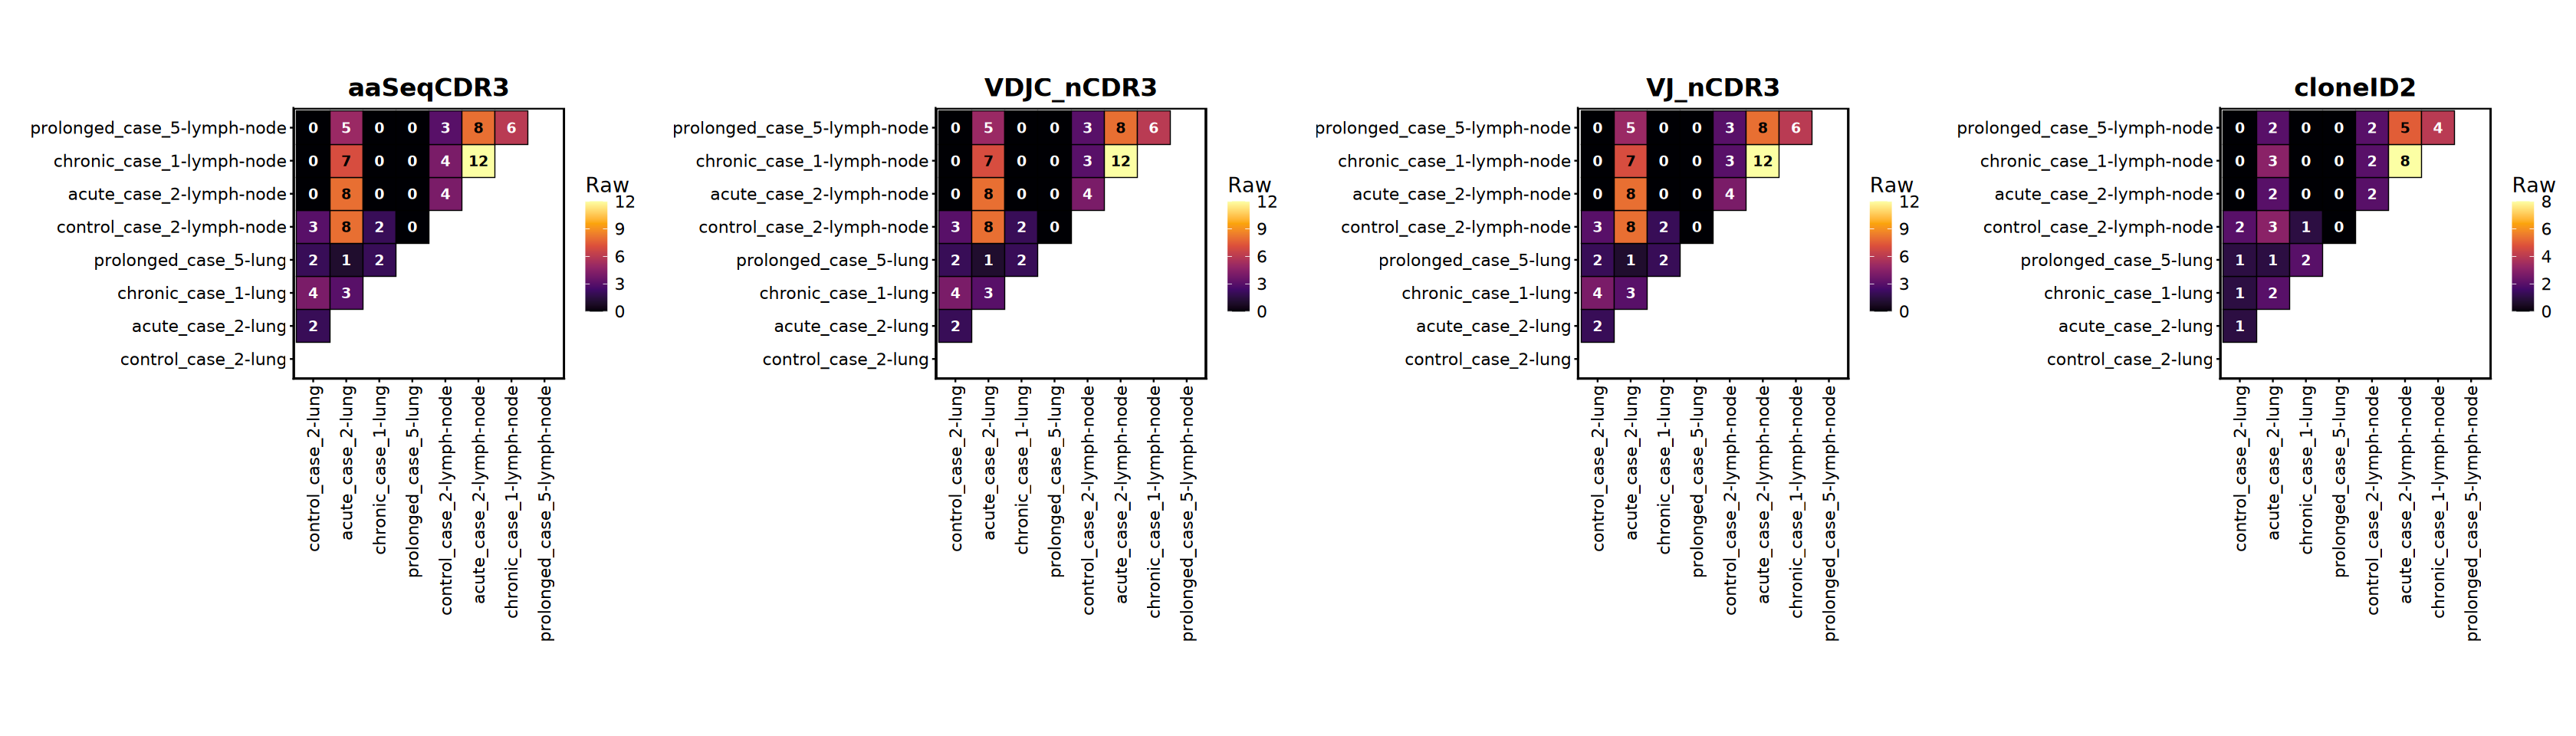

In [28]:
cond_tissue_levels <- c("control_case_2-lung", "acute_case_2-lung", "chronic_case_1-lung", "prolonged_case_5-lung",
                        "control_case_2-lymph-node", "acute_case_2-lymph-node", "chronic_case_1-lymph-node", "prolonged_case_5-lymph-node")

check_shared_clones <- function(sample1, sample2, clone_def = "cloneID2") {
    shared_aa <- intersect(tcr_df %>% filter(cond_tissue == sample1) %>% pull(aaSeqCDR3) %>% unique(),
                           tcr_df %>% filter(cond_tissue == sample2) %>% pull(aaSeqCDR3) %>% unique())
    tcr_df %>% filter(cond_tissue %in% c(sample1, sample2), aaSeqCDR3 %in% shared_aa) %>%
        group_by(aaSeqCDR3) %>%
        summarise(n_clone = n_distinct(!!sym(clone_def)),
                  same_clone = n_distinct(!!sym(clone_def)) == 1,
                  clone_values = paste(unique(!!sym(clone_def)), collapse = " | "),
                  .groups = "drop") %>%
        arrange(desc(same_clone)) %>%
        mutate(comparison = paste0(sample1, " vs ", sample2),
               clone_def = clone_def)
}

check_shared_clones("acute_case_2-lung", "acute_case_2-lymph-node", "VDJC_nCDR3")
check_shared_clones("control_case_2-lung", "control_case_2-lymph-node", "VDJC_nCDR3")

check_shared_clones("acute_case_2-lung", "acute_case_2-lymph-node", "VJ_nCDR3")
check_shared_clones("control_case_2-lung", "control_case_2-lymph-node", "VJ_nCDR3")

check_shared_clones("acute_case_2-lung", "acute_case_2-lymph-node", "cloneID2")
check_shared_clones("control_case_2-lung", "control_case_2-lymph-node", "cloneID2")

options(repr.plot.width = 28, repr.plot.height = 8, warn = -1)
samples <- cond_tissue_levels

make_overlap_matrix <- function(tcr_df, clone_def, samples) {
    sapply(samples, function(i) sapply(samples, function(j) {
        length(intersect(tcr_df %>% filter(cond_tissue == i) %>% pull(!!sym(clone_def)),
                         tcr_df %>% filter(cond_tissue == j) %>% pull(!!sym(clone_def))))}))
}

mat_aa <- make_overlap_matrix(tcr_df, "aaSeqCDR3", samples)
mat_clone <- make_overlap_matrix(tcr_df, "cloneID2", samples)
mat_vdjc <- make_overlap_matrix(tcr_df, "VDJC_nCDR3", samples)
mat_vj <- make_overlap_matrix(tcr_df, "VJ_nCDR3", samples)

make_raw_heatmap <- function(mat, title) {
    as.data.frame(mat) %>%
        tibble::rownames_to_column("sample1") %>%
        pivot_longer(cols = -sample1, names_to = "sample2", values_to = "overlap") %>%
        mutate(sample1 = factor(sample1, levels = cond_tissue_levels),
               sample2 = factor(sample2, levels = cond_tissue_levels),
               overlap = ifelse(as.integer(sample1) <= as.integer(sample2), NA, overlap)) %>%
        filter(!is.na(overlap)) %>%
        mutate(text_color = ifelse(overlap > max(overlap, na.rm = TRUE) / 2, "black", "white")) %>%
    ggplot(aes(x = sample2, y = sample1, fill = overlap)) +
        geom_tile(color = "black", linewidth = 0.3) +
        geom_text(aes(label = round(overlap, 0), color = text_color), fontface = "bold") +
        scale_color_identity() +
        scale_fill_viridis_c(option = "inferno", name = "Raw", direction = 1) +
        scale_x_discrete(drop = FALSE) +
        scale_y_discrete(drop = FALSE) +
        labs(x = "", y = "", title = title) +
        theme_classic() +
        theme(text = element_text(size = 16),
              axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5),
              panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
              plot.title = element_text(hjust = 0.5, face = "bold"),
              panel.background = element_rect(fill = "white")) +
        coord_fixed()
}

make_raw_heatmap(mat_aa, "aaSeqCDR3") | make_raw_heatmap(mat_vdjc, "VDJC_nCDR3") |  make_raw_heatmap(mat_vj, "VJ_nCDR3") | make_raw_heatmap(mat_clone, "cloneID2")

**Clonotype definitions are nearly equivalent**

The two definitions based on nucleotide CDR3 plus gene usage (`VJ_nCDR3` and `VDJC_nCDR3`) yield identical clonotype counts globally (**958**) and per condition, confirming that D and C gene usage add no discriminating power beyond V, J, and CDR3 sequence. 

The full-nucleotide chain definitions (nSeq_full and cloneID2) are likewise identical to each other (**980**), but higher than the CDR3+V/J definitions, reflecting additional fragmentation driven by sequence variation in the framework regions outside the CDR3.

Switching to the amino acid CDR3 definition reduces the total from **958 to 957** clonotypes (relative to VJ_nCDR3/VDJC_nCDR3), a loss of only 1 (**0.1%**), driven by convergent recombination: **99.9%** of aa CDR3s map uniquely to a single nucleotide-level clone, while the remaining 0.1% collapse 2 nucleotide variants into a single aa sequence. Relative to the full-nucleotide definition (cloneID2, 980), the amino acid CDR3 definition instead resolves **98.4%** of aa CDR3s to a single nucleotide clone, with the remaining 1.6% collapsing 2–4 nucleotide variants per amino acid sequence, the larger gap here reflecting framework-region noise rather than true convergent recombination.

**Cross-organ sharing is slightly increased under the relaxed definition**
Cross-organ clonotype sharing under the amino acid CDR3 definition is slightly increased relative to the full nucleotide sequence definition (cloneID2), reflecting the collapsing of nucleotide variants encoding the same amino acid sequence. However, shared clones between the lung and draining lymph node within the same patient remain exactly identical between the amino acid CDR3 and nucleotide CDR3+V/J (VJ_nCDR3) definitions, indicating that the additional sharing observed under the relaxed definition arises specifically from convergent recombination across different patients, rather than from any loss of resolution in detecting true within-patient clonal sharing.

**Justification for using aa CDR3 as the primary clonotype definition**
Taken together, these results strongly support the use of amino acid CDR3 sequence as the primary clonotype definition for cross-sample analyses:

- **Minimal information loss:** 99.9% of aa CDR3s map uniquely to a single nucleotide-level clone under the CDR3+V/J definition, meaning the two definitions are nearly equivalent in this dataset.
- **Functional relevance:** aa CDR3 sequence is the primary determinant of antigen recognition; clones sharing the same aa CDR3 are expected to recognise the same epitopes regardless of their nucleotide origin.
- **Cleaner interpretability:** the amino acid CDR3 sequence provides a compact, human-readable clone identifier, in contrast to the long composite strings required by nucleotide-based definitions, making downstream reporting, labeling, and visualization more tractable.

## Basic clonal analysis

Now, we can start by looking at the total number of clonotypes in each sample.

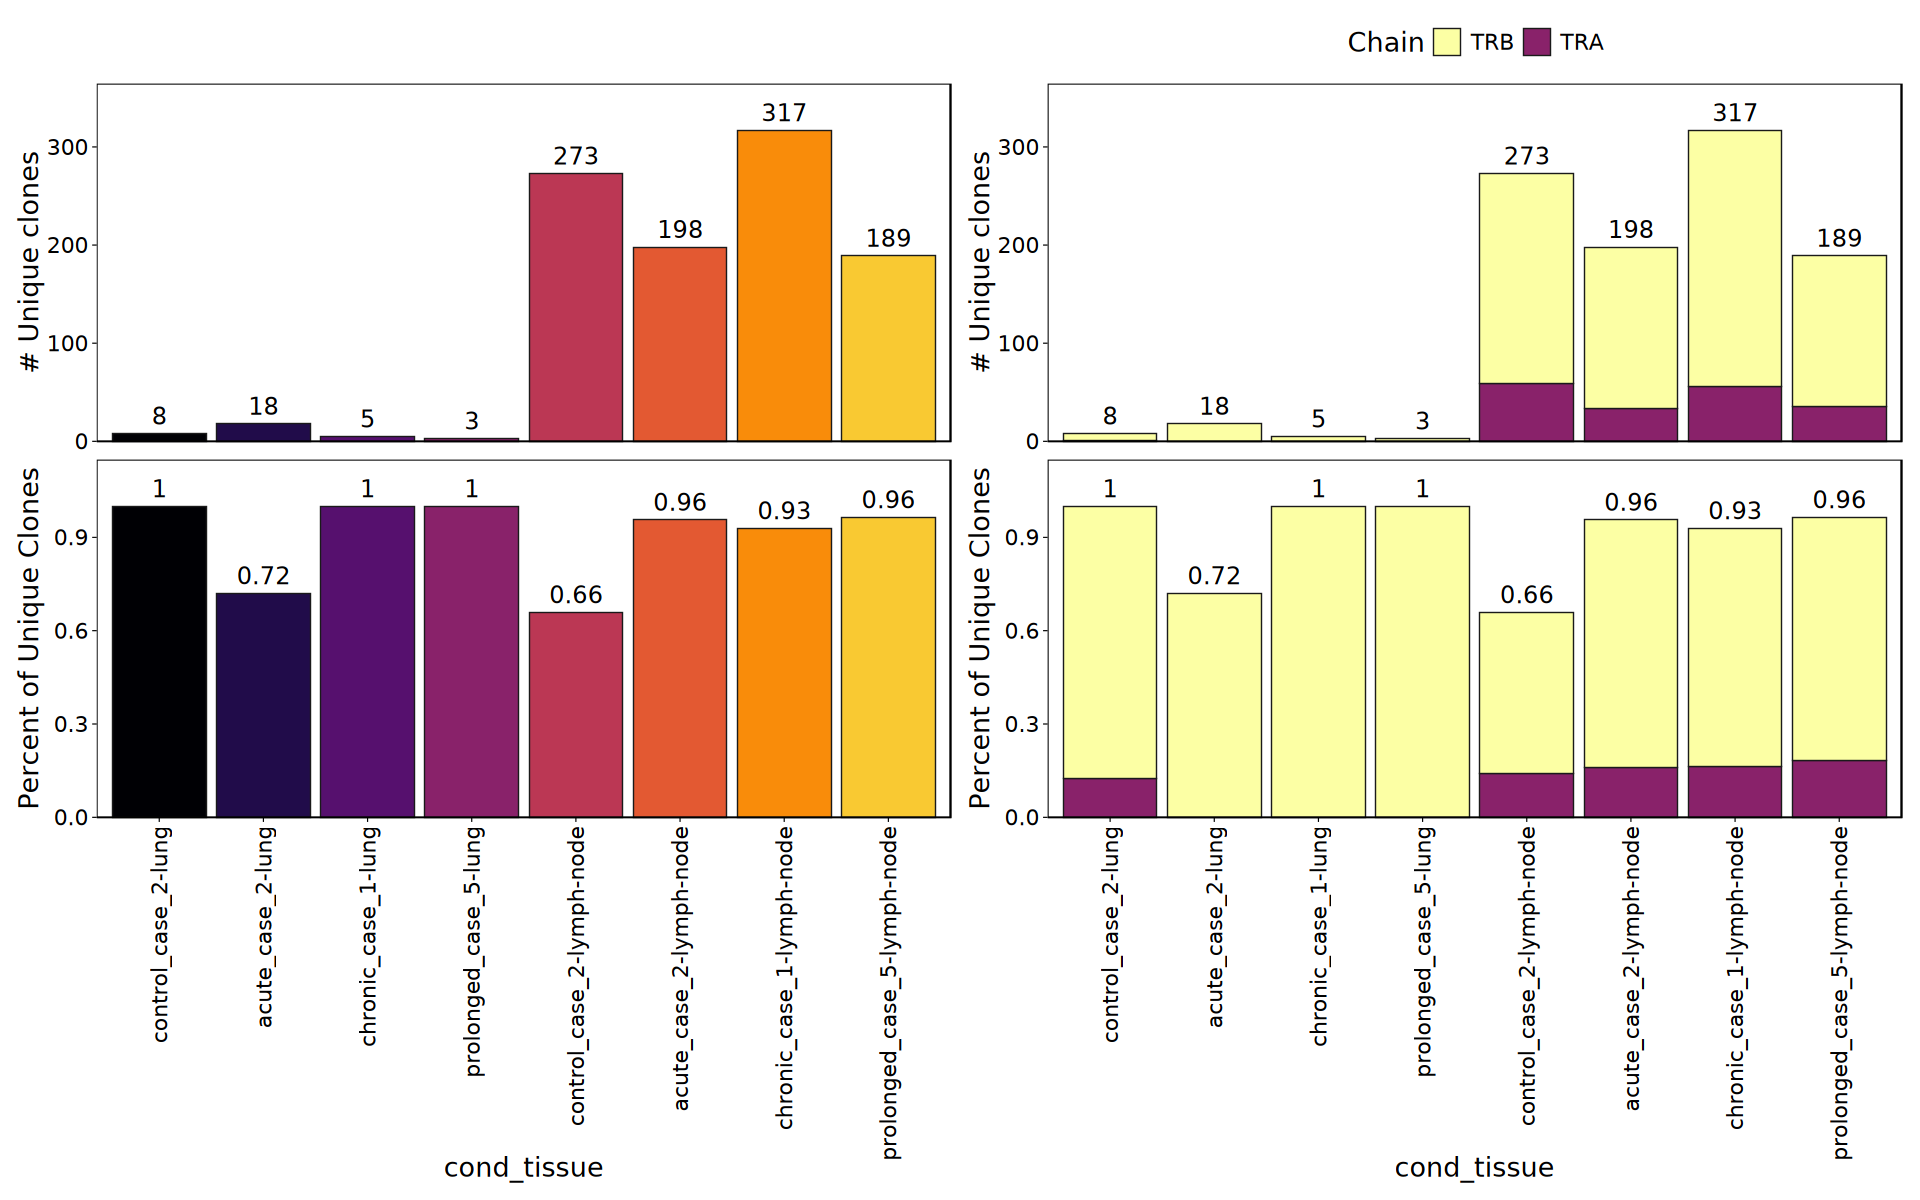

In [7]:
options(repr.plot.width = 16, repr.plot.height = 10, warn = -1)

chain_colors <- c("TRA" = "#89226A", "TRB" = "#FCFFA4")
clone_counts <- tcr_df %>%
    group_by(cond_tissue, chain) %>%
    summarise(clones = n_distinct(aaSeqCDR3), rows = n(), .groups = "drop") %>%
    group_by(cond_tissue) %>%
    mutate(prop = clones / sum(rows),
           chain = factor(chain, levels = c("TRB", "TRA"))) %>%
    ungroup() %>%
    mutate(cond_tissue = factor(cond_tissue, levels = cond_tissue_levels))

clone_totals <- clone_counts %>%
    group_by(cond_tissue) %>%
    summarise(clones = sum(clones), prop = sum(prop), .groups = "drop") %>%
    mutate(cond_tissue = factor(cond_tissue, levels = cond_tissue_levels))

p1 <- ggplot(clone_totals, aes(x = cond_tissue, y = clones, fill = cond_tissue)) +
    geom_col(color = "grey10", linewidth = 0.3) +
    geom_text(aes(label = clones), vjust = -0.5, color = "black", size = 5) +
    scale_y_continuous(limits = c(0, max(clone_totals$clones) * 1.15),
                       expand = expansion(mult = c(0, 0))) +
    scale_fill_manual(values = viridis::inferno(9)) +
    labs(y = "# Unique clones") +
    theme_linedraw() +
    theme(legend.position = "none",
          panel.grid = element_blank(),
          text = element_text(size = 16),
          axis.text.x = element_blank(),
          axis.title.x = element_blank(),
          axis.ticks.x = element_blank())

p2 <- ggplot(clone_totals, aes(x = cond_tissue, y = prop, fill = cond_tissue)) +
    geom_col(color = "grey10", linewidth = 0.3) +
    geom_text(aes(label = round(prop, 2), y = prop), vjust = -0.5, color = "black", size = 5) +
    scale_y_continuous(limits = c(0, max(clone_counts$prop) * 1.15),
                       expand = expansion(mult = c(0, 0))) +
    scale_fill_manual(values = viridis::inferno(9)) +
    labs(y = "Percent of Unique Clones") +
    theme_linedraw() +
    theme(legend.position = "none",
          panel.grid = element_blank(),
          text = element_text(size = 16),
          axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5))

p3 <- ggplot(clone_counts, aes(x = cond_tissue, y = clones, fill = chain)) +
    geom_col(color = "grey10", linewidth = 0.3, position = "stack") +
    geom_text(data = clone_totals, aes(label = clones, fill = NULL),
              vjust = -0.5, color = "black", size = 5) +
    scale_y_continuous(limits = c(0, max(clone_totals$clones) * 1.15),
                       expand = expansion(mult = c(0, 0))) +
    scale_fill_manual(values = chain_colors, name = "Chain") +
    labs(y = "# Unique clones") +
    theme_linedraw() +
    theme(legend.position = "top",
          text = element_text(size = 16),
          panel.grid = element_blank(),
          axis.text.x = element_blank(),
          axis.title.x = element_blank(),
          axis.ticks.x = element_blank())

p4 <- ggplot(clone_counts, aes(x = cond_tissue, y = prop, fill = chain)) +
    geom_col(color = "grey10", linewidth = 0.3, position = "stack") +
    geom_text(data = clone_totals, aes(label = round(prop, 2), fill = NULL),
              vjust = -0.5, color = "black", size = 5) +
    scale_y_continuous(limits = c(0, max(clone_totals$prop) * 1.15),
                       expand = expansion(mult = c(0, 0))) +
    scale_fill_manual(values = chain_colors, name = "Chain") +
    labs(y = "Percent of Unique Clones") +
    theme_linedraw() +
    theme(legend.position = "none",
          panel.grid = element_blank(),
          text = element_text(size = 16),
          axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5))

ggsave("~/SP-COVID/analysis/TCR/out/plots/clone_counts.svg", plot = p1 / p2, width = 8, height = 10)
ggsave("~/SP-COVID/analysis/TCR/out/plots/clone_counts_chain.svg", plot = p3 / p4, width = 8, height = 10)
p1 / p2 | p3 / p4

We can do the same by tissue, we can see that we have more unique clonotyes in lymph-nodes compared to lungs.

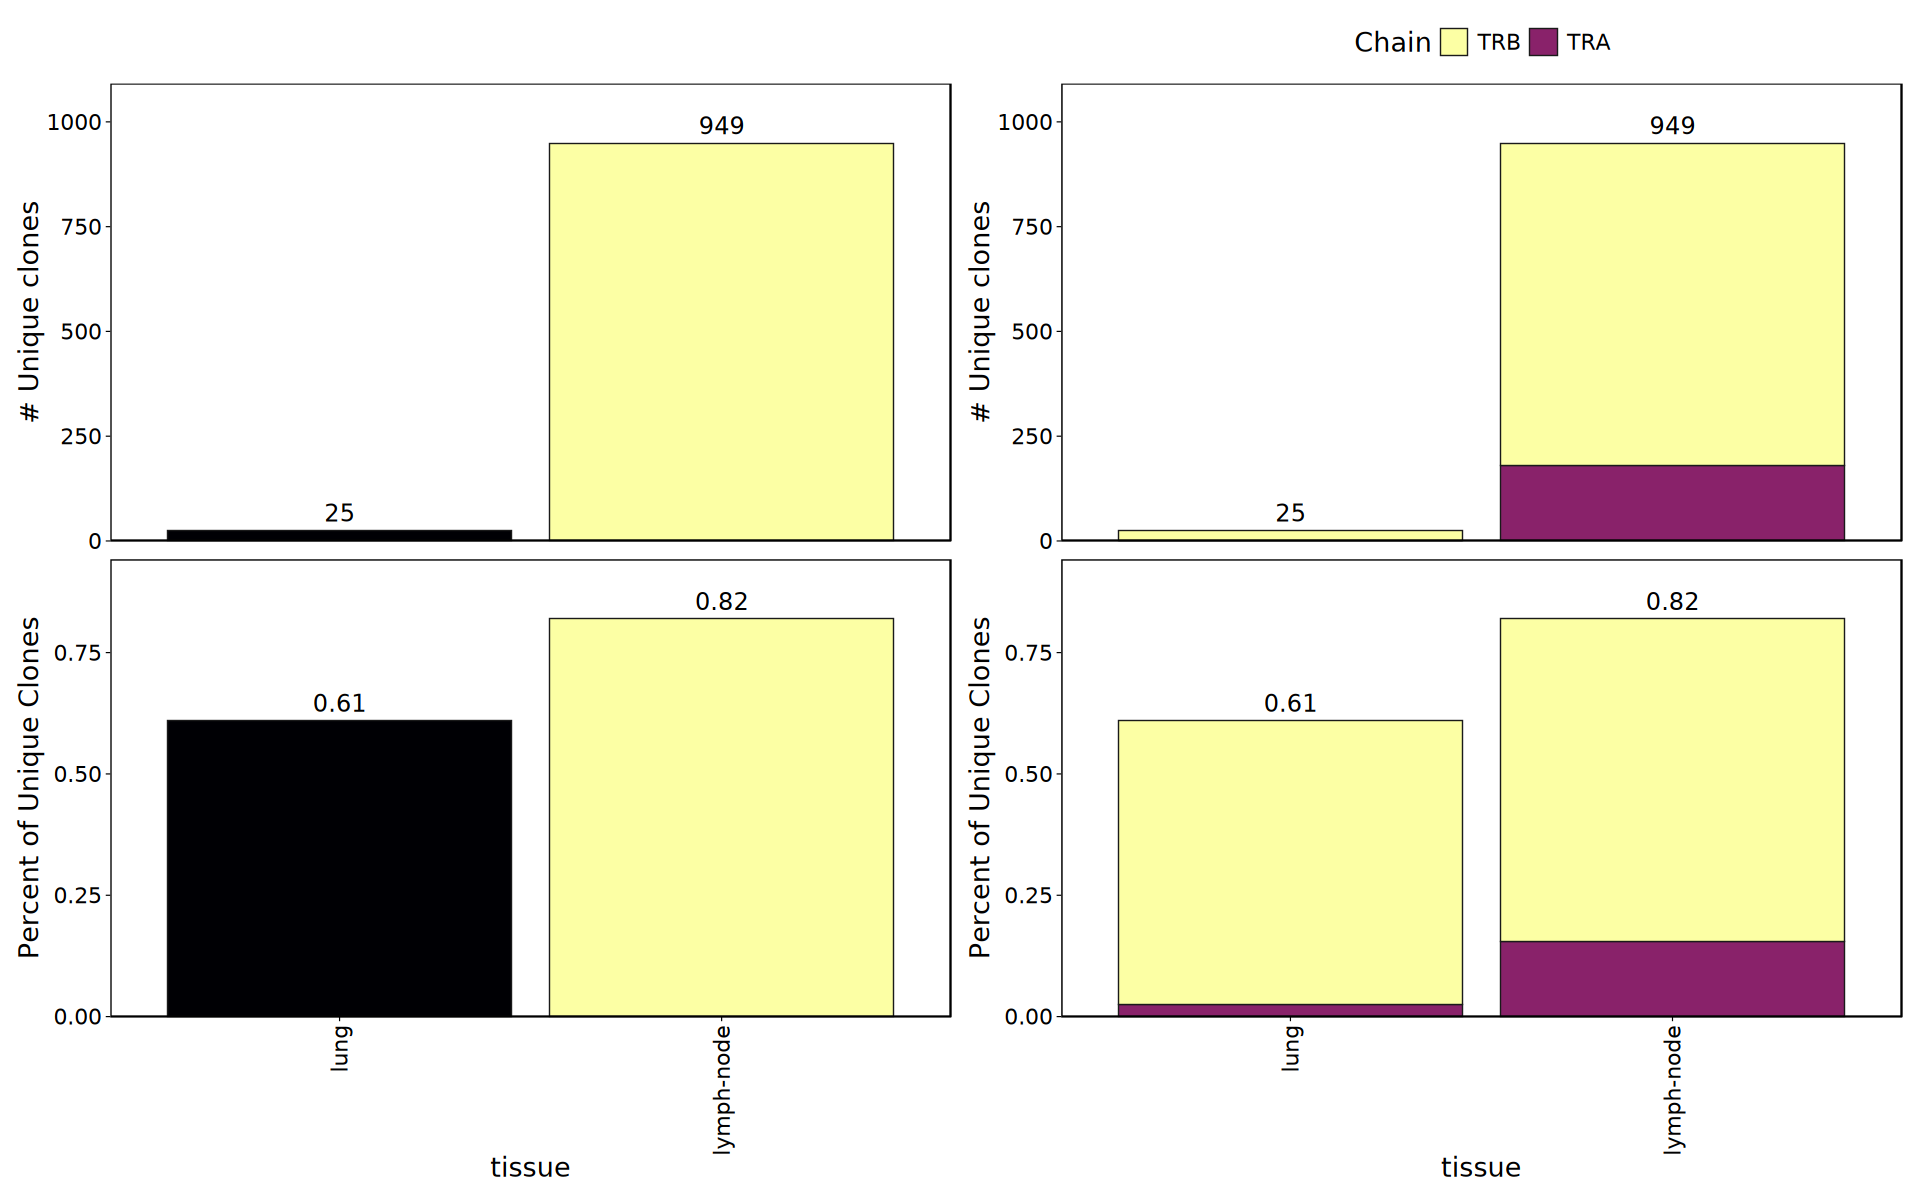

In [8]:
clone_counts <- tcr_df %>%
    group_by(tissue, chain) %>%
    summarise(clones = n_distinct(aaSeqCDR3), rows = n(), .groups = "drop") %>%
    group_by(tissue) %>%
    mutate(prop = clones / sum(rows),
           chain = factor(chain, levels = c("TRB", "TRA"))) %>%
    ungroup()

clone_totals <- clone_counts %>%
    group_by(tissue) %>%
    summarise(clones = sum(clones), prop = sum(prop), .groups = "drop")

p1 <- ggplot(clone_totals, aes(x = tissue, y = clones, fill = tissue)) +
    geom_col(color = "grey10", linewidth = 0.3) +
    geom_text(aes(label = clones), vjust = -0.5, color = "black", size = 5) +
    scale_y_continuous(limits = c(0, max(clone_totals$clones) * 1.15),
                       expand = expansion(mult = c(0, 0))) +
    scale_fill_manual(values = viridis::inferno(2)) +
    labs(y = "# Unique clones") +
    theme_linedraw() +
    theme(legend.position = "none",
          text = element_text(size = 16),
          panel.grid = element_blank(),
          axis.text.x = element_blank(),
          axis.title.x = element_blank(),
          axis.ticks.x = element_blank())

p2 <- ggplot(clone_totals, aes(x = tissue, y = prop, fill = tissue)) +
    geom_col(color = "grey10", linewidth = 0.3) +
    geom_text(aes(label = round(prop, 2)), vjust = -0.5, color = "black", size = 5) +
    scale_y_continuous(limits = c(0, max(clone_totals$prop) * 1.15),
                       expand = expansion(mult = c(0, 0))) +
    scale_fill_manual(values = viridis::inferno(2)) +
    labs(y = "Percent of Unique Clones") +
    theme_linedraw() +
    theme(legend.position = "none",
          panel.grid = element_blank(),
          text = element_text(size = 16),
          axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5))

p3 <- ggplot(clone_counts, aes(x = tissue, y = clones, fill = chain)) +
    geom_col(color = "grey10", linewidth = 0.3, position = "stack") +
    geom_text(data = clone_totals, aes(label = clones, fill = NULL),
              vjust = -0.5, color = "black", size = 5) +
    scale_y_continuous(limits = c(0, max(clone_totals$clones) * 1.15),
                       expand = expansion(mult = c(0, 0))) +
    scale_fill_manual(values = chain_colors, name = "Chain") +
    labs(y = "# Unique clones") +
    theme_linedraw() +
    theme(legend.position = "top",
          text = element_text(size = 16),
          panel.grid = element_blank(),
          axis.text.x = element_blank(),
          axis.title.x = element_blank(),
          axis.ticks.x = element_blank())

p4 <- ggplot(clone_counts, aes(x = tissue, y = prop, fill = chain)) +
    geom_col(color = "grey10", linewidth = 0.3, position = "stack") +
    geom_text(data = clone_totals, aes(label = round(prop, 2), fill = NULL),
              vjust = -0.5, color = "black", size = 5) +
    scale_y_continuous(limits = c(0, max(clone_totals$prop) * 1.15),
                       expand = expansion(mult = c(0, 0))) +
    scale_fill_manual(values = chain_colors, name = "Chain") +
    labs(y = "Percent of Unique Clones") +
    theme_linedraw() +
    theme(legend.position = "none",
          panel.grid = element_blank(),
          text = element_text(size = 16),
          axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5))

p1 / p2 | p3 / p4

Finally, we can also check it by disease stage.

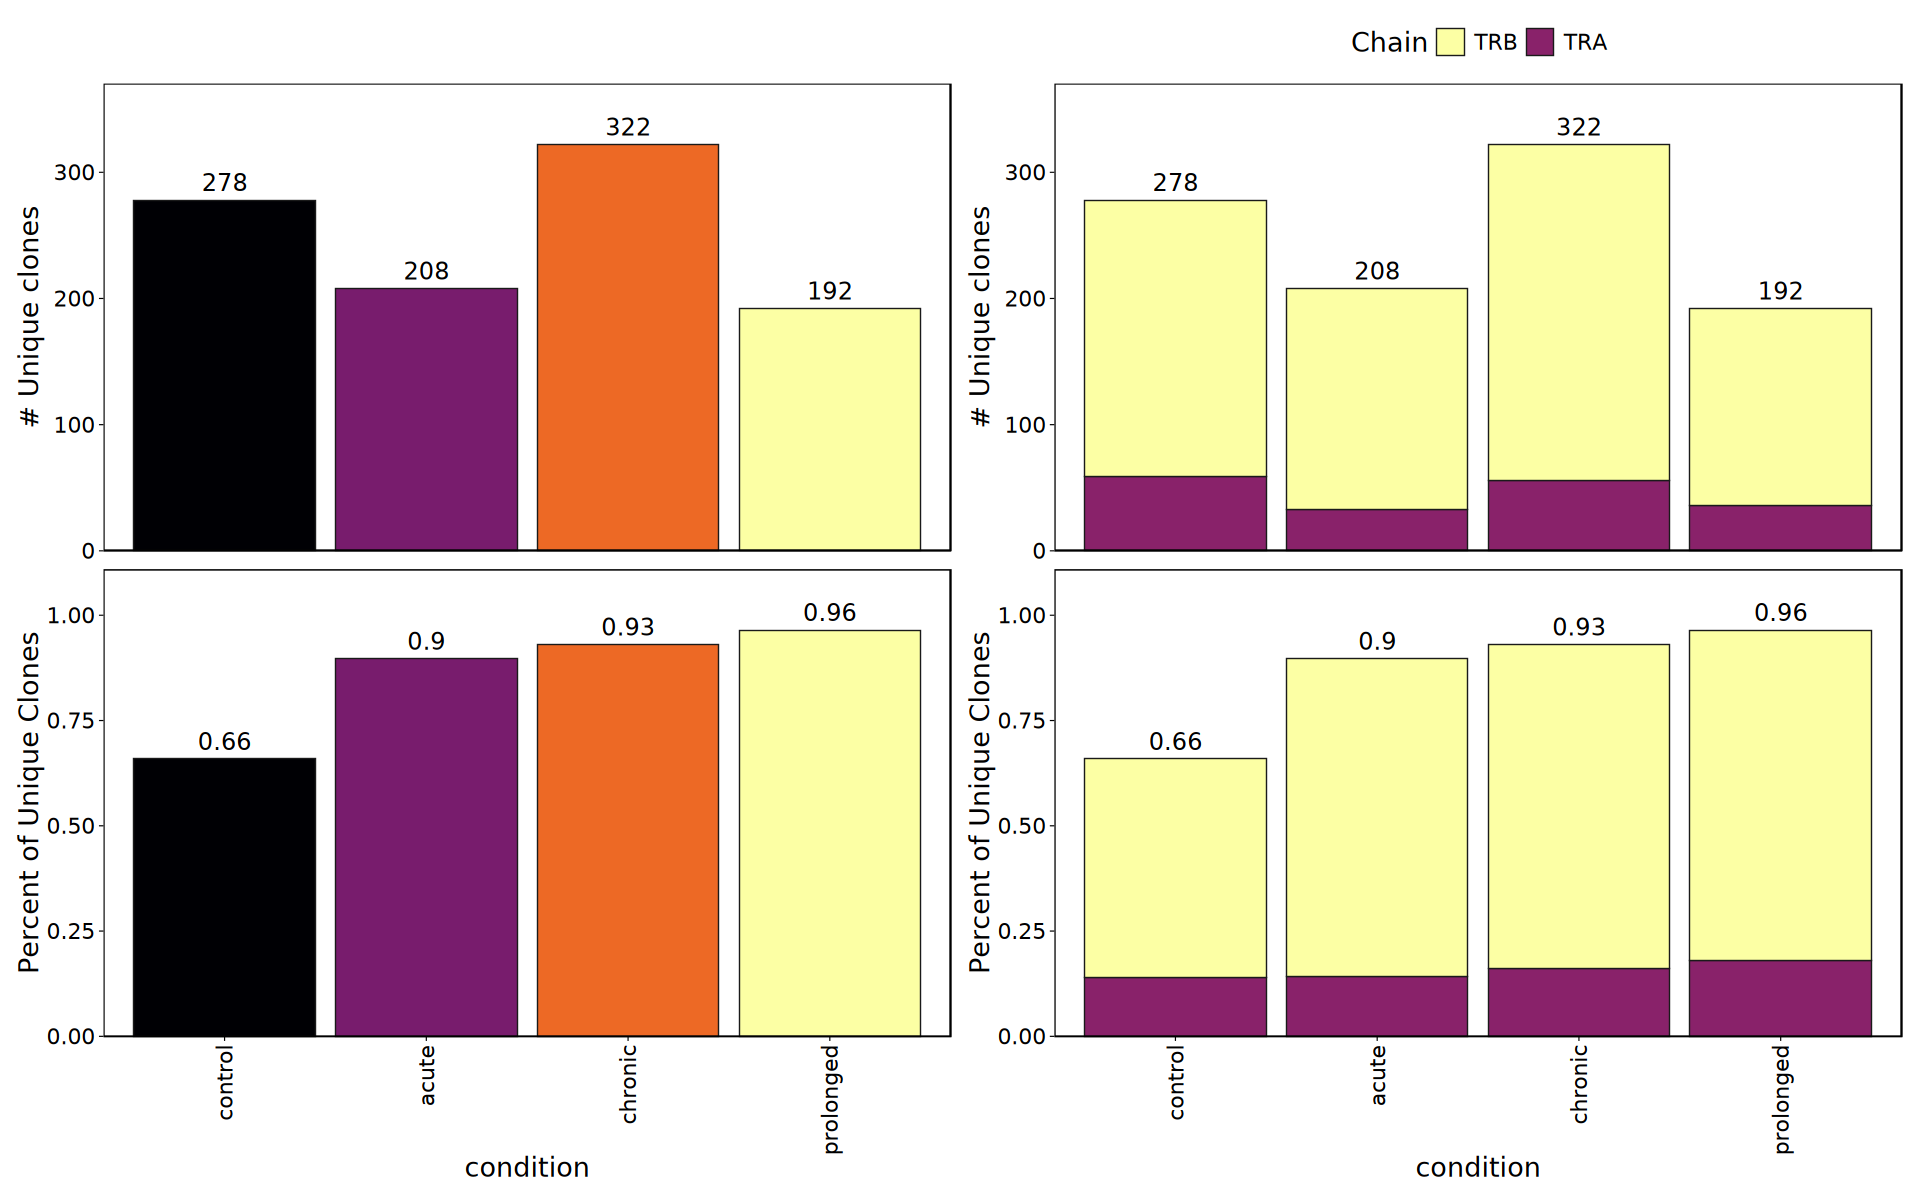

In [9]:
condition_levels <- c("control", "acute", "chronic", "prolonged")

clone_counts <- tcr_df %>%
    group_by(condition, chain) %>%
    summarise(clones = n_distinct(aaSeqCDR3), rows = n(), .groups = "drop") %>%
    group_by(condition) %>%
    mutate(prop = clones / sum(rows),
           chain = factor(chain, levels = c("TRB", "TRA"))) %>%
    ungroup() %>%
    mutate(condition = factor(condition, levels = condition_levels))

clone_totals <- clone_counts %>%
    group_by(condition) %>%
    summarise(clones = sum(clones), prop = sum(prop), .groups = "drop") %>%
    mutate(condition = factor(condition, levels = condition_levels))

p1 <- ggplot(clone_totals, aes(x = condition, y = clones, fill = condition)) +
    geom_col(color = "grey10", linewidth = 0.3) +
    geom_text(aes(label = clones), vjust = -0.5, color = "black", size = 5) +
    scale_y_continuous(limits = c(0, max(clone_totals$clones) * 1.15),
                       expand = expansion(mult = c(0, 0))) +
    scale_fill_manual(values = viridis::inferno(4)) +
    labs(y = "# Unique clones") +
    theme_linedraw() +
    theme(legend.position = "none",
          text = element_text(size = 16),
          panel.grid = element_blank(),
          axis.text.x = element_blank(),
          axis.title.x = element_blank(),
          axis.ticks.x = element_blank())

p2 <- ggplot(clone_totals, aes(x = condition, y = prop, fill = condition)) +
    geom_col(color = "grey10", linewidth = 0.3) +
    geom_text(aes(label = round(prop, 2)), vjust = -0.5, color = "black", size = 5) +
    scale_y_continuous(limits = c(0, max(clone_totals$prop) * 1.15),
                       expand = expansion(mult = c(0, 0))) +
    scale_fill_manual(values = viridis::inferno(4)) +
    labs(y = "Percent of Unique Clones") +
    theme_linedraw() +
    theme(legend.position = "none",
          panel.grid = element_blank(),
          text = element_text(size = 16),
          axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5))

p3 <- ggplot(clone_counts, aes(x = condition, y = clones, fill = chain)) +
    geom_col(color = "grey10", linewidth = 0.3, position = "stack") +
    geom_text(data = clone_totals, aes(label = clones, fill = NULL),
              vjust = -0.5, color = "black", size = 5) +
    scale_y_continuous(limits = c(0, max(clone_totals$clones) * 1.15),
                       expand = expansion(mult = c(0, 0))) +
    scale_fill_manual(values = chain_colors, name = "Chain") +
    labs(y = "# Unique clones") +
    theme_linedraw() +
    theme(legend.position = "top",
          text = element_text(size = 16),
          panel.grid = element_blank(),
          axis.text.x = element_blank(),
          axis.title.x = element_blank(),
          axis.ticks.x = element_blank())

p4 <- ggplot(clone_counts, aes(x = condition, y = prop, fill = chain)) +
    geom_col(color = "grey10", linewidth = 0.3, position = "stack") +
    geom_text(data = clone_totals, aes(label = round(prop, 2), fill = NULL),
              vjust = -0.5, color = "black", size = 5) +
    scale_y_continuous(limits = c(0, max(clone_totals$prop) * 1.15),
                       expand = expansion(mult = c(0, 0))) +
    scale_fill_manual(values = chain_colors, name = "Chain") +
    labs(y = "Percent of Unique Clones") +
    theme_linedraw() +
    theme(legend.position = "none",
          panel.grid = element_blank(),
          text = element_text(size = 16),
          axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5))

p1 / p2 | p3 / p4

We can also explore the distribution of UMI counts for each sample.

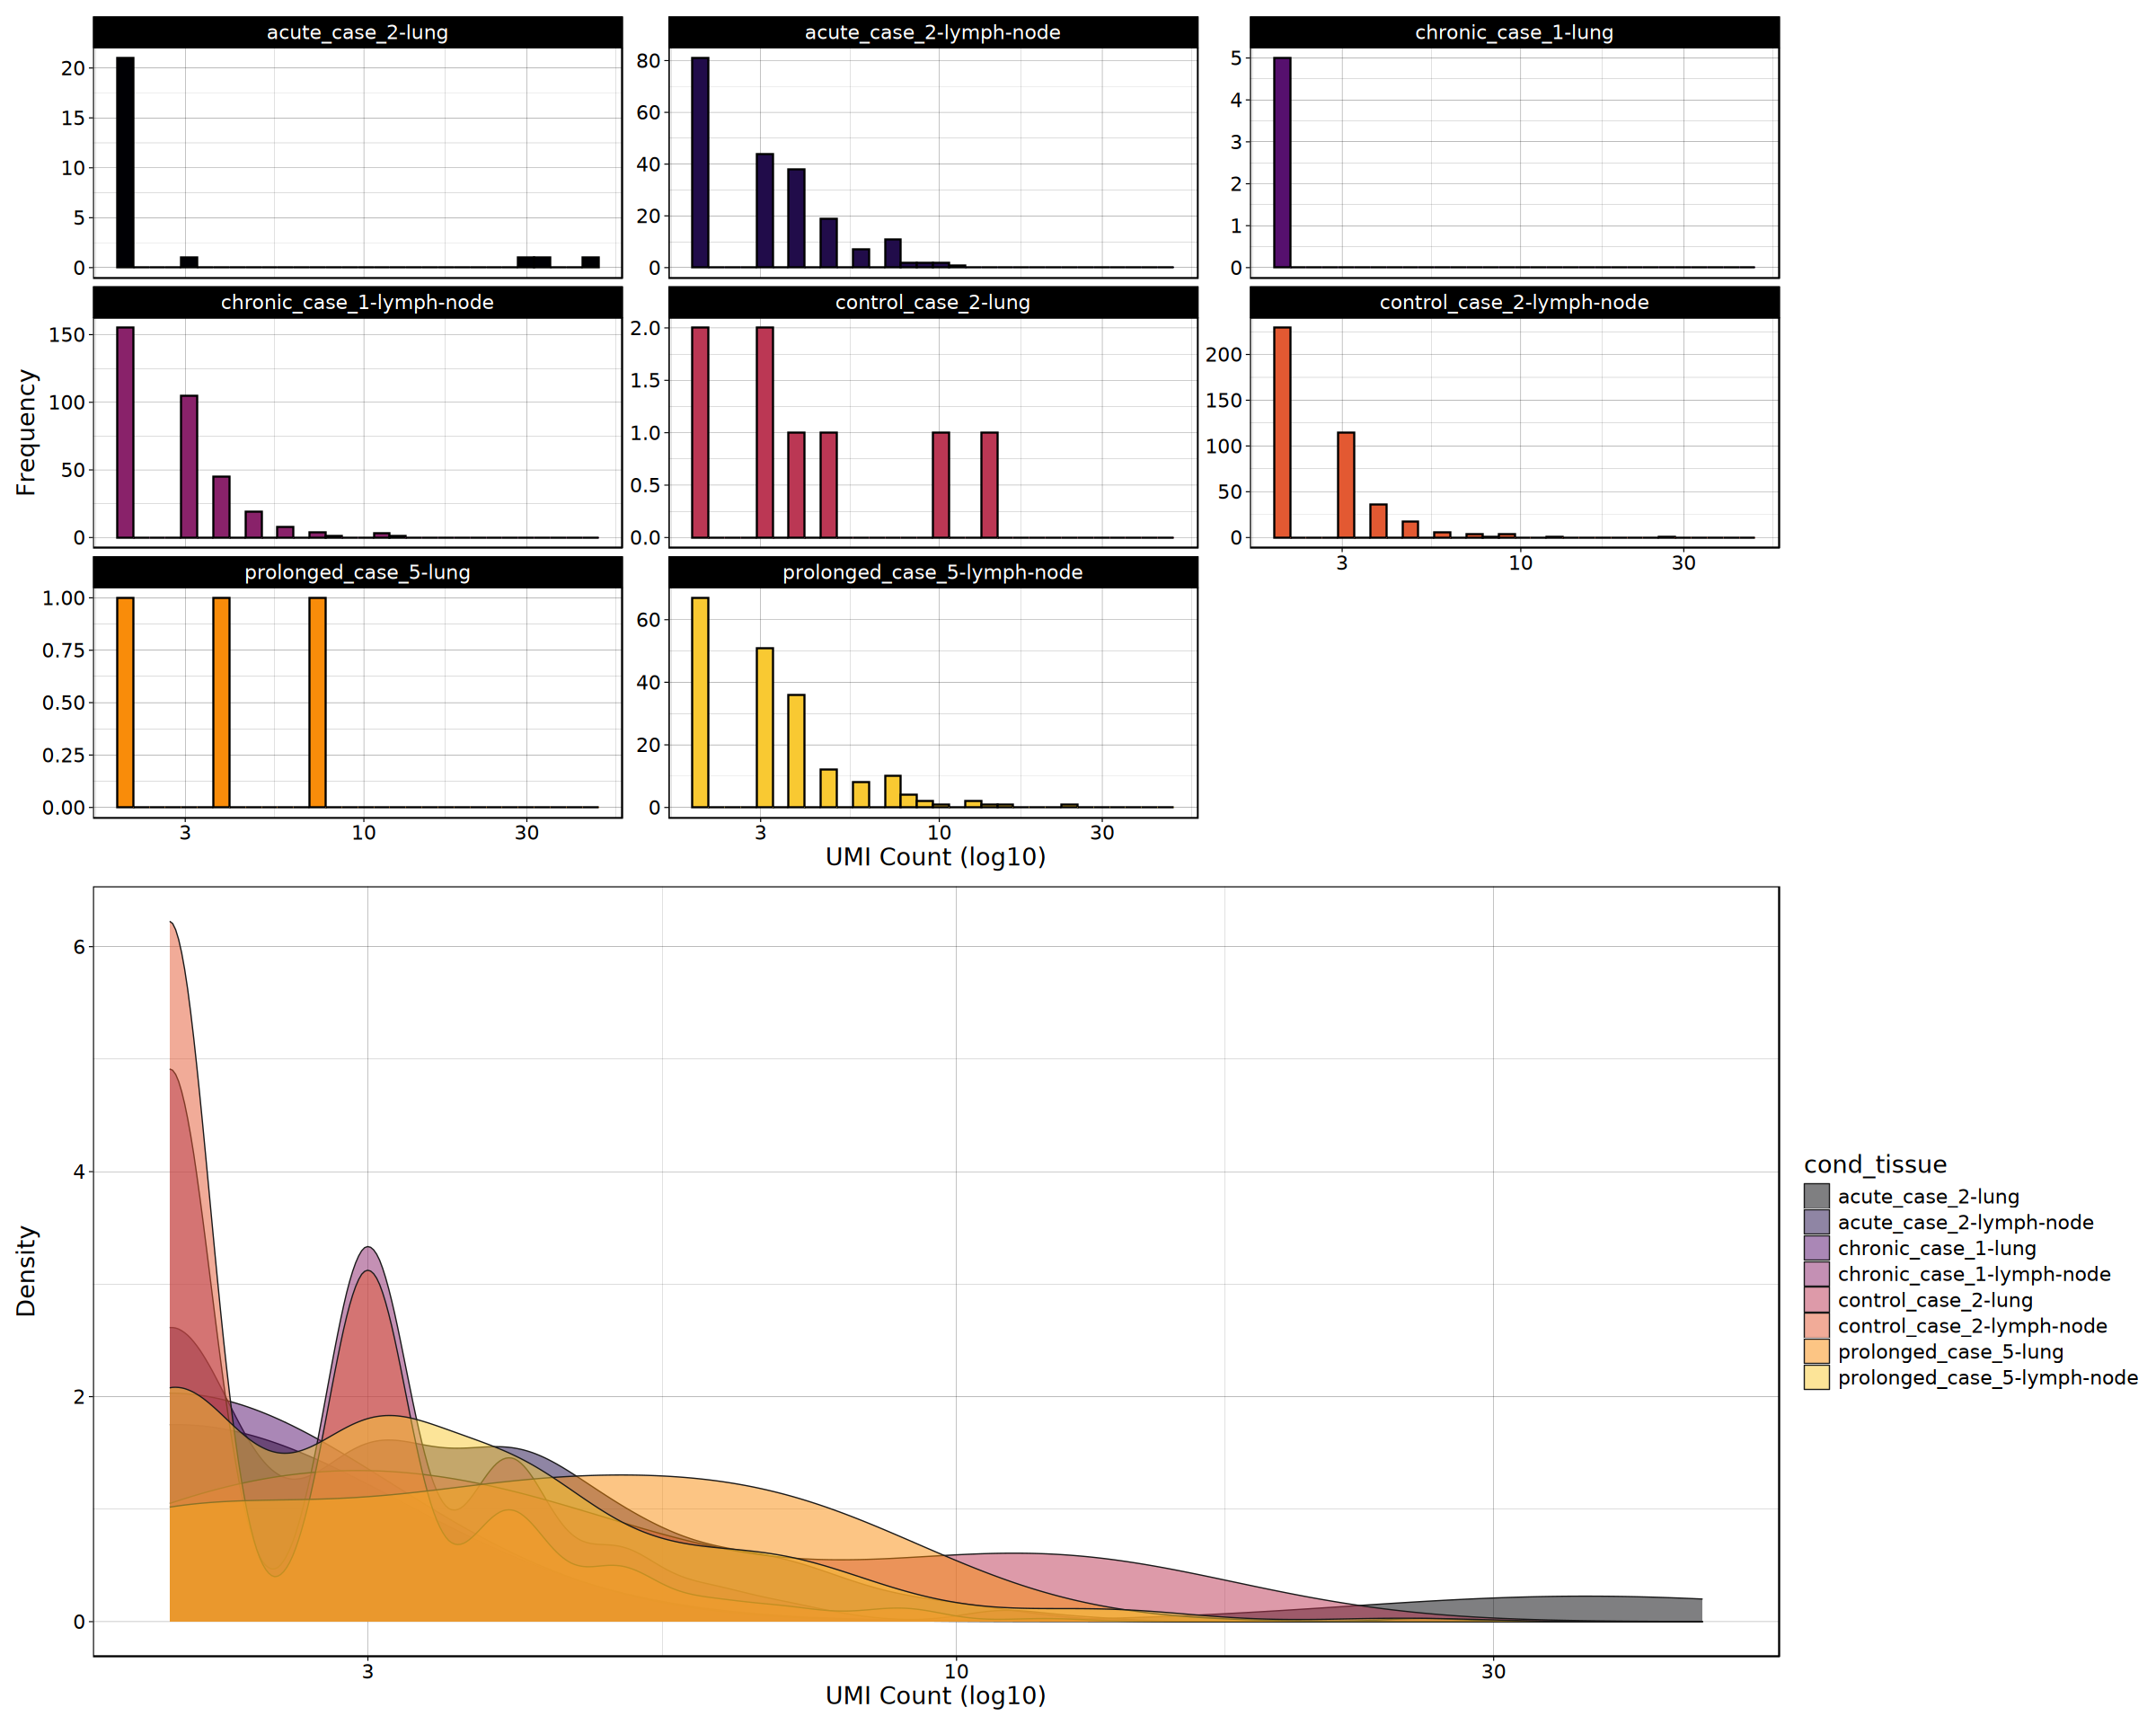

In [10]:
options(repr.plot.width = 20, repr.plot.height = 16, warn = -1)

p1 <- ggplot(tcr_df, aes(x = uniqueMoleculeCount, fill = cond_tissue)) +
    geom_histogram(bins = 30, color = "black") +
    scale_fill_manual(values = viridis::inferno(9)) +
    scale_x_log10() +
    facet_wrap(~cond_tissue, scales = "free_y") +
    labs(x = "UMI Count (log10)", y = "Frequency") +
    theme_linedraw() +
    theme(legend.position = "none",
          text = element_text(size = 16))

p2 <- ggplot(tcr_df, aes(x = uniqueMoleculeCount, fill = cond_tissue)) +
    geom_density(alpha = 0.5, color = "grey10", linewidth = 0.3) +
    scale_fill_manual(values = viridis::inferno(9)) +
    scale_x_log10() +
    labs(x = "UMI Count (log10)",  y = "Density") +
    theme_linedraw() +
    theme(text = element_text(size = 16),
          legend.position = "right")

p1 / p2

Next, we can explore the distribution of sequence lengths by looking at the length distribution of the CDR3 amino acid sequences by chain, and both together. 

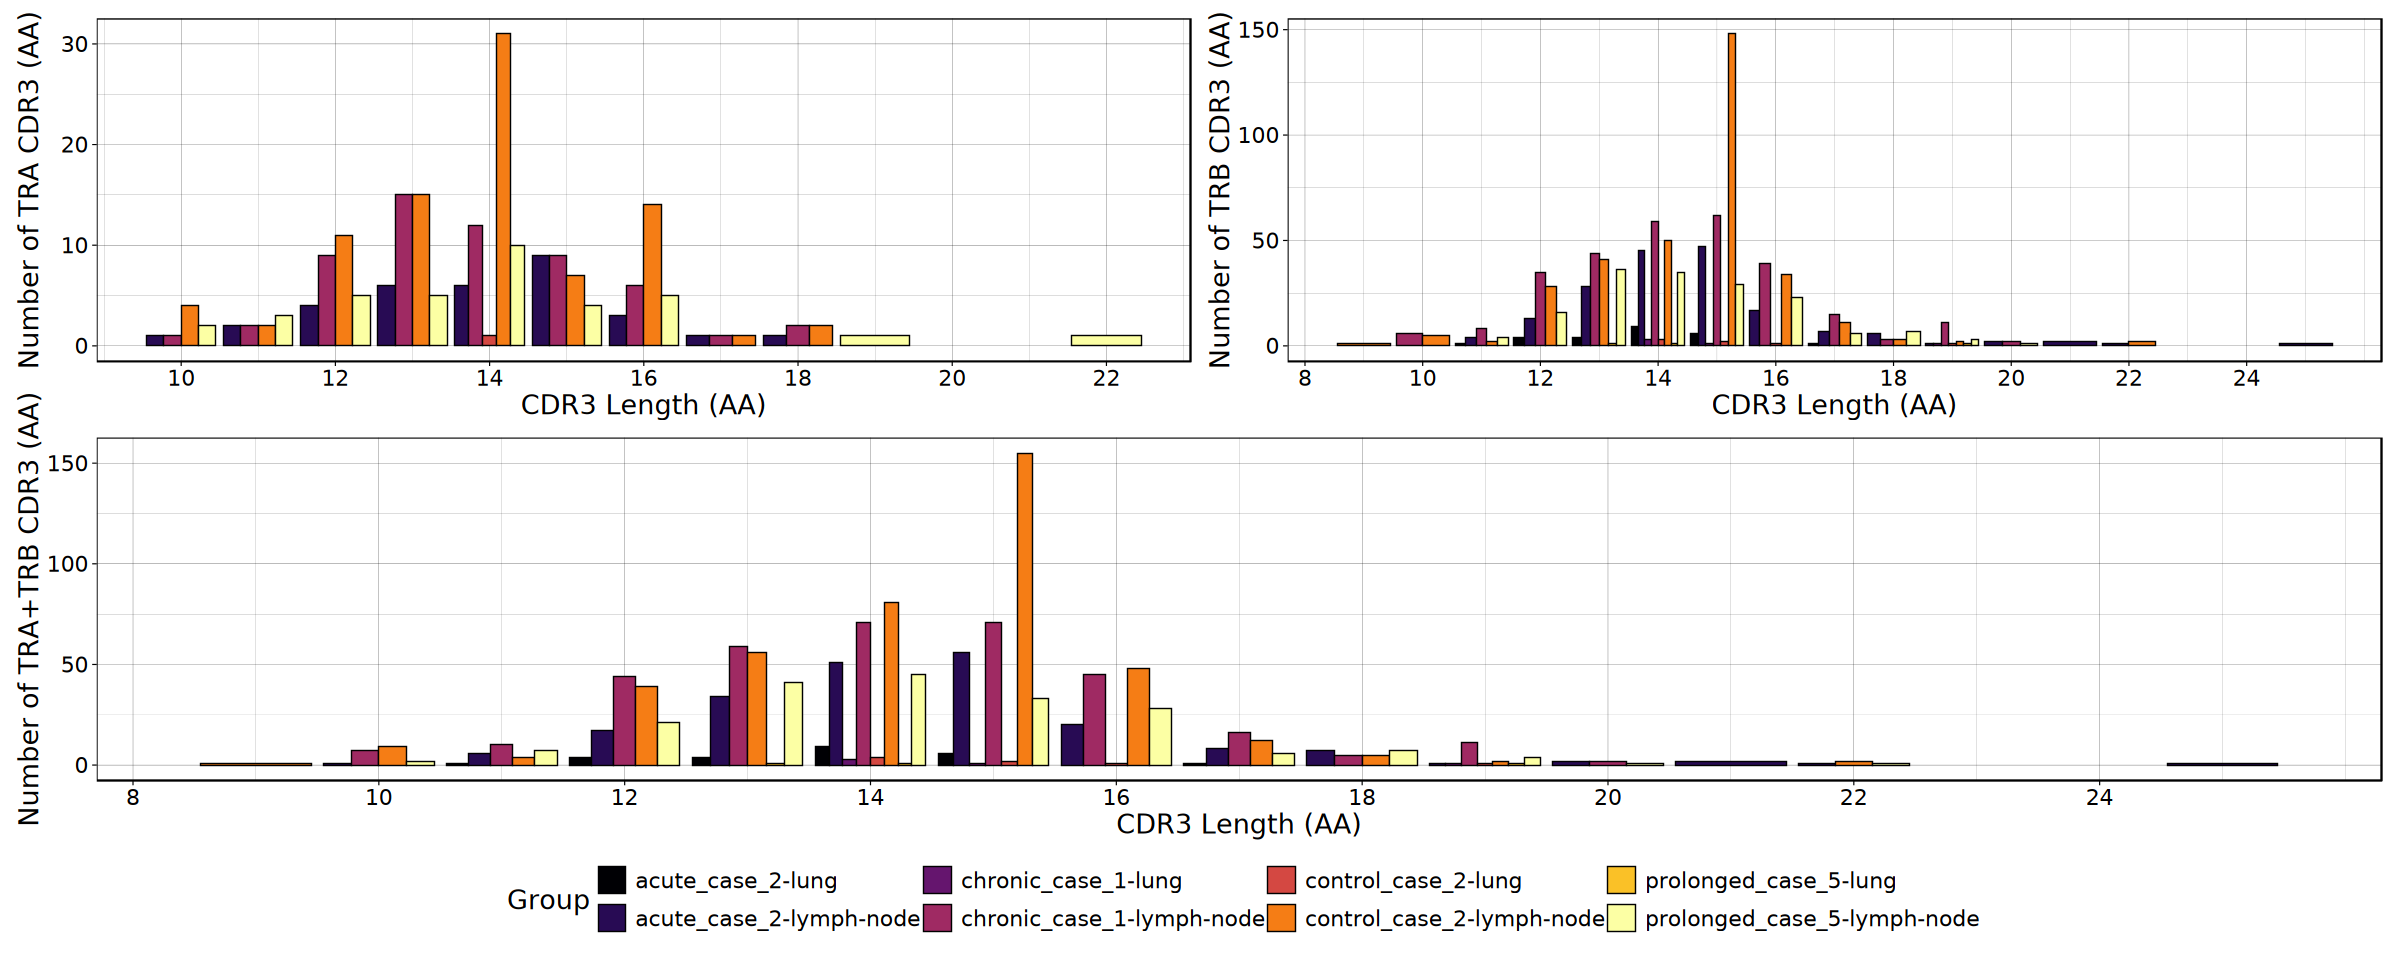

In [11]:
options(repr.plot.width = 20, repr.plot.height = 8, warn = -1)

sample_colors <- setNames(viridis::inferno(n_distinct(tcr_df$cond_tissue)),
                          sort(unique(tcr_df$cond_tissue)))

p1 <- tcr_df %>%
  filter(chain == "TRA") %>%
  group_by(cond_tissue, cdr3_length) %>%
  summarise(count = n(), .groups = "drop") %>%
  ggplot(aes(x = cdr3_length, y = count, fill = cond_tissue)) +
  geom_bar(stat = "identity", position = "dodge", color = "black", linewidth = 0.3) +
  scale_x_continuous(breaks = seq(0, max(tcr_df$cdr3_length, na.rm = TRUE), by = 2)) +
  scale_fill_manual(values = sample_colors) +
  labs(x = "CDR3 Length (AA)", y = "Number of TRA CDR3 (AA)", fill = "Group") +
  theme_linedraw() +
  theme(legend.position = "none",
        text = element_text(size = 16))

p2 <- tcr_df %>%
  filter(chain == "TRB") %>%
  group_by(cond_tissue, cdr3_length) %>%
  summarise(count = n(), .groups = "drop") %>%
  ggplot(aes(x = cdr3_length, y = count, fill = cond_tissue)) +
  geom_bar(stat = "identity", position = "dodge", color = "black", linewidth = 0.3) +
  scale_x_continuous(breaks = seq(0, max(tcr_df$cdr3_length, na.rm = TRUE), by = 2)) +
  scale_fill_manual(values = sample_colors) +
  labs(x = "CDR3 Length (AA)", y = "Number of TRB CDR3 (AA)", fill = "Group") +
  theme_linedraw() +
  theme(legend.position = "none",
        text = element_text(size = 16))

p3 <- tcr_df %>%
  filter(chain %in% c("TRA", "TRB")) %>%
  group_by(cond_tissue, cdr3_length) %>%
  summarise(count = n(), .groups = "drop") %>%
  ggplot(aes(x = cdr3_length, y = count, fill = cond_tissue)) +
  geom_bar(stat = "identity", position = "dodge", color = "black", linewidth = 0.3) +
  scale_x_continuous(breaks = seq(0, max(tcr_df$cdr3_length, na.rm = TRUE), by = 2)) +
  scale_fill_manual(values = sample_colors) +
  labs(x = "CDR3 Length (AA)", y = "Number of TRA+TRB CDR3 (AA)", fill = "Group") +
  theme_linedraw() +
  theme(legend.position = "bottom",
        text = element_text(size = 16))

(p1 | p2) / p3

## Repertoires summary

To summarize CDR3 sequence composition, we will analyze the relative amino-acid usage across all TRB CDR3 sequences. We will quantify the proportion of each amino acid across the repertoire, providing a global view of biochemical constraints and selection acting on the antigen-recognition region. This will provide us insights into the amino acid composition and variability at each residue, which can be indicative of functional constraints or selection pressures on the CDR3.

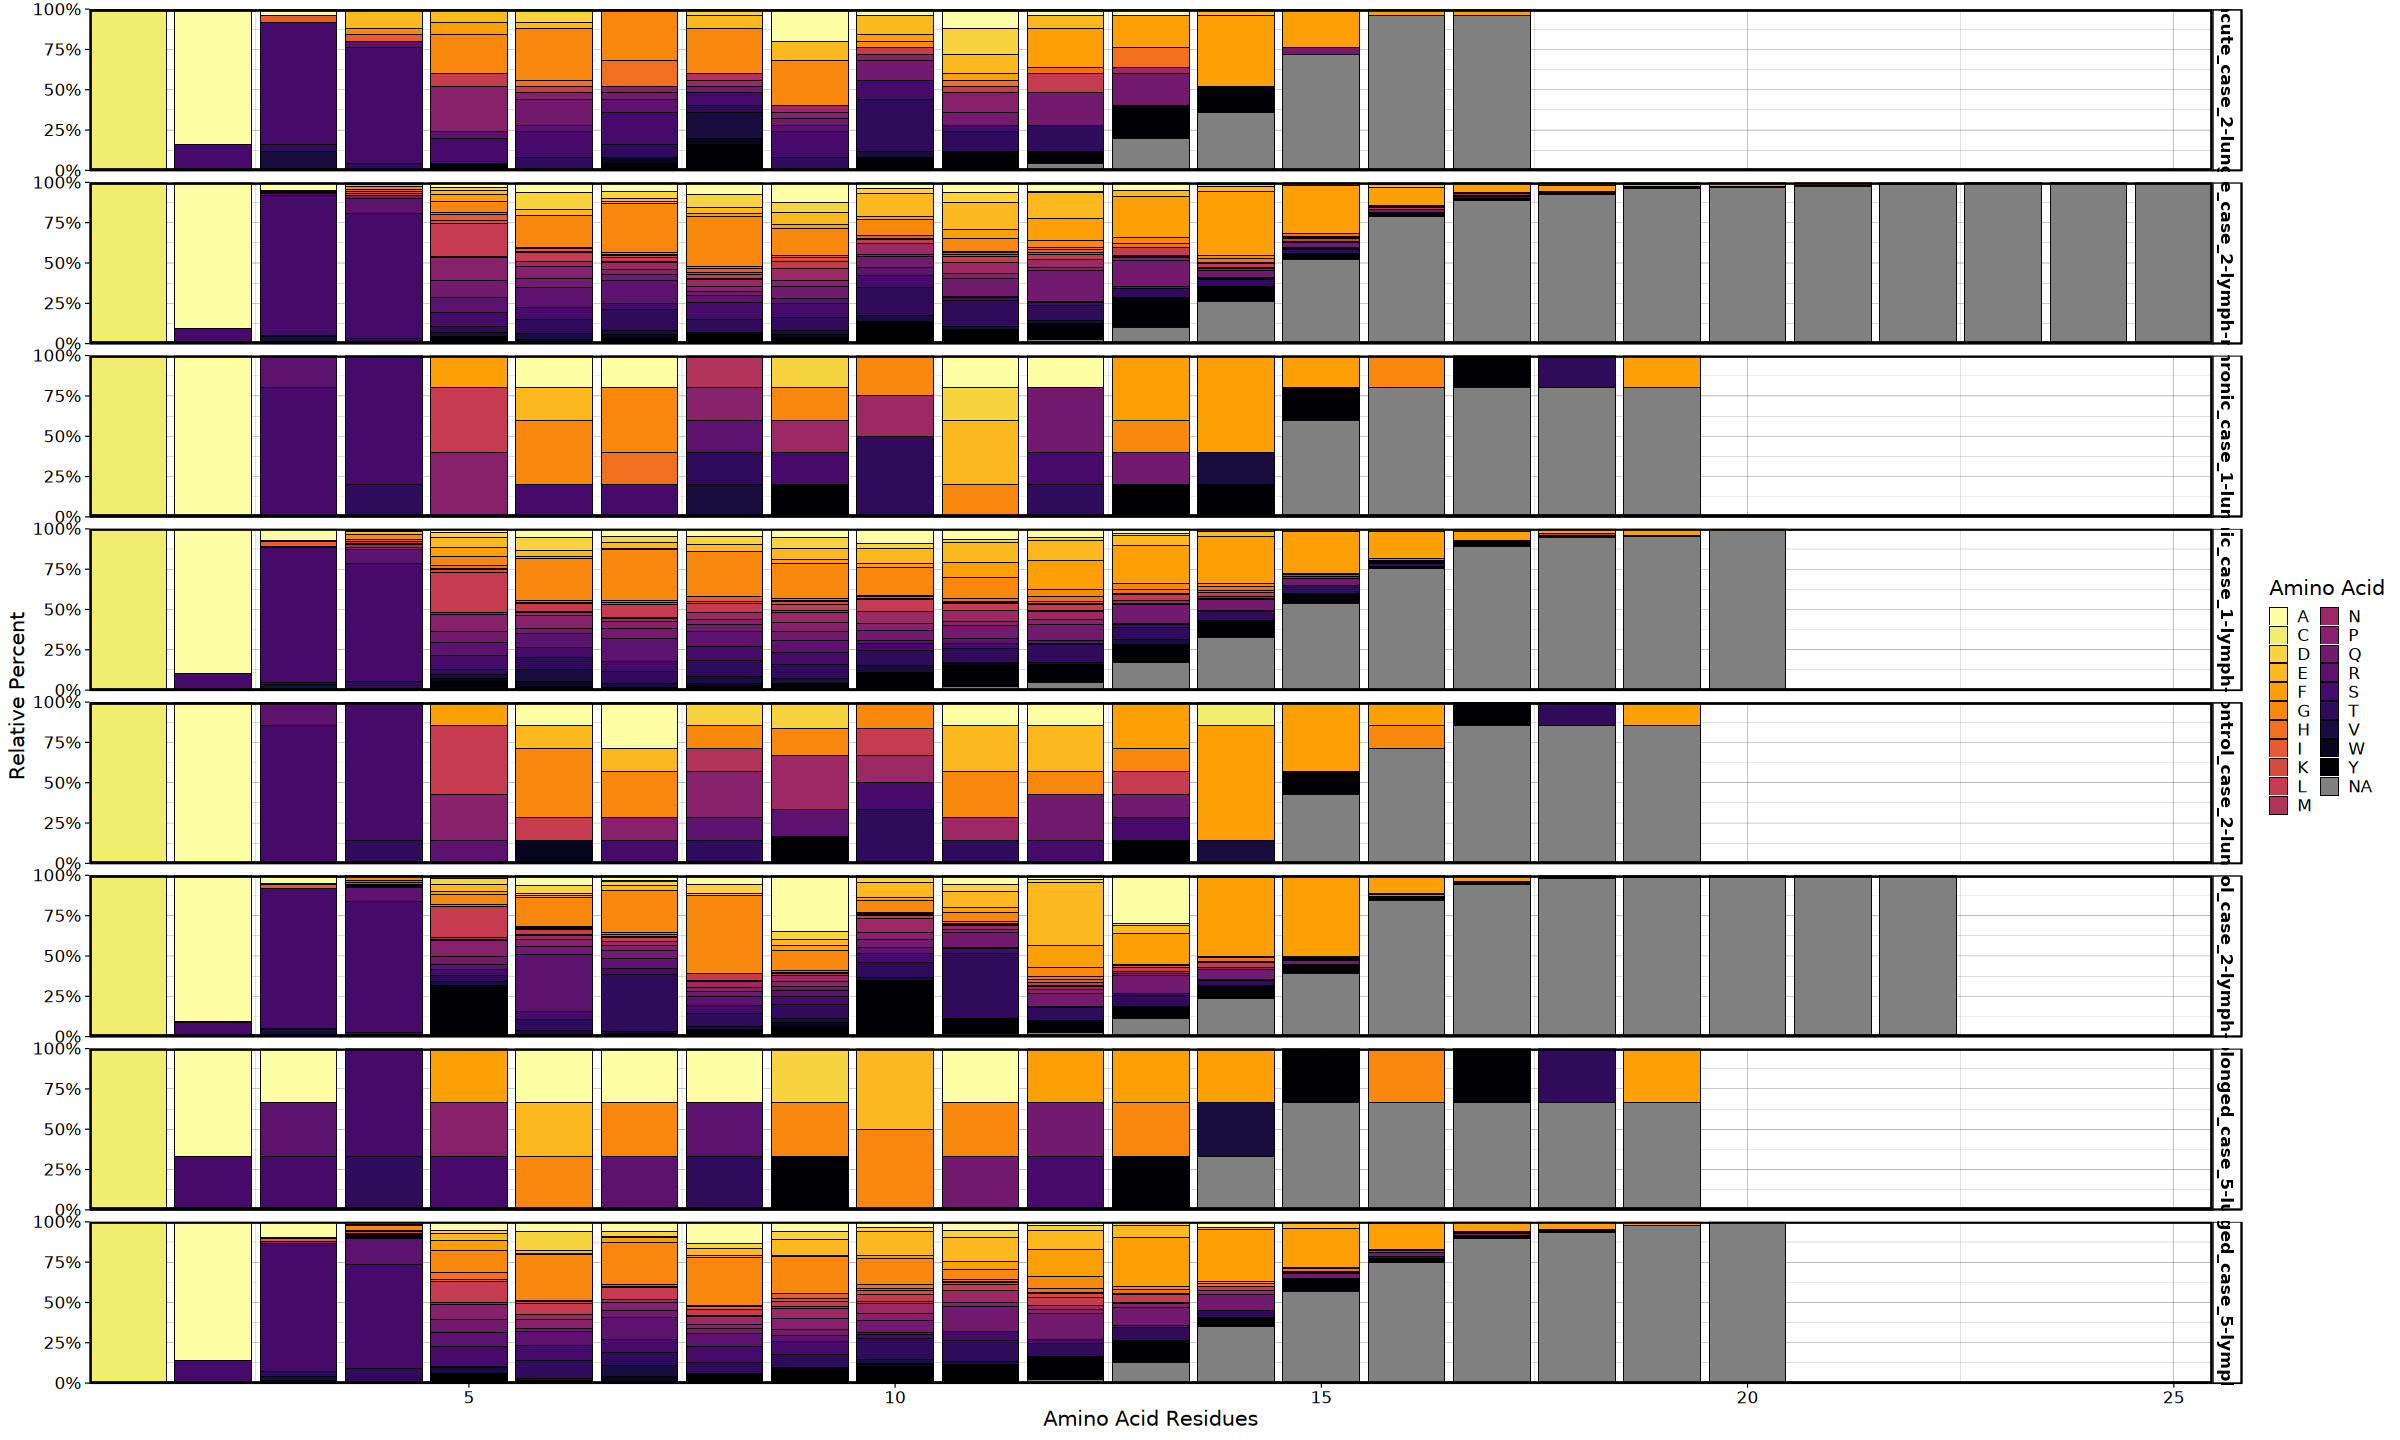

In [12]:
options(repr.plot.width = 20, repr.plot.height = 12, warn = -1)

trb_data <- tcr_df %>% 
  filter(chain == "TRB" & !is.na(aaSeqCDR3) & aaSeqCDR3 != "")

calculate_aa_frequencies_by_sample <- function(df) {
    # Function to calculate amino acid frequencies per position for each sample
    all_aa <- c("A", "C", "D", "E", "F", "G", "H", "I", "K", "L", "M", "N", "P", "Q", "R", "S", "T", "V", "W", "Y", "NA")
      
    results_list <- list()
    global_max_length <- max(nchar(as.character(df$aaSeqCDR3)), na.rm = TRUE)
      
    for (sample in unique(df$cond_tissue)) {
        sample_seqs <- df %>% 
            filter(cond_tissue == sample) %>% 
            pull(aaSeqCDR3)
        
        n_seqs <- length(sample_seqs)
        
        aa_matrix <- matrix(0, nrow = length(all_aa), ncol = global_max_length, 
                            dimnames = list(all_aa, paste0("Pos", 1:global_max_length)))
        
        for (seq in sample_seqs) {
            if (!is.na(seq) && seq != "") {
                seq_chars <- strsplit(as.character(seq), "")[[1]]
                seq_length <- length(seq_chars)
            
            for (pos in 1:global_max_length) {
              if (pos <= seq_length) {
                aa <- seq_chars[pos]
                
                if (aa %in% all_aa[1:20]) {  
                  aa_matrix[aa, pos] <- aa_matrix[aa, pos] + 1
                }
              } else {
                aa_matrix["NA", pos] <- aa_matrix["NA", pos] + 1
              }
            }
          }
        }
        
        aa_freq <- sweep(aa_matrix, 2, colSums(aa_matrix), FUN = "/") * 100
        aa_freq[is.nan(aa_freq)] <- 0
        
        aa_freq_long <- as.data.frame(aa_freq) %>%
          tibble::rownames_to_column("amino_acid") %>%
          pivot_longer(cols = starts_with("Pos"), 
                       names_to = "position", 
                       values_to = "percentage") %>%
          mutate(position = as.numeric(gsub("Pos", "", position)),
                 sample = sample)
        
        positions_to_keep <- aa_freq_long %>%
          group_by(position) %>%
          summarise(has_aa = sum(percentage[amino_acid != "NA"]) > 0, .groups = "drop") %>%
          filter(has_aa) %>%
          pull(position)
        
        aa_freq_long <- aa_freq_long %>%
          filter(position %in% positions_to_keep) %>%
          filter(percentage > 0) 
        
        results_list[[sample]] <- aa_freq_long
    }
    results <- bind_rows(results_list)
    return(results)
}

aa_freq_data <- calculate_aa_frequencies_by_sample(trb_data)

aa_order <- c("A", "C", "D", "E", "F", "G", "H", "I", "K", "L", 
              "M", "N", "P", "Q", "R", "S", "T", "V", "W", "Y", "NA")
aa_freq_data$amino_acid <- factor(aa_freq_data$amino_acid, levels = aa_order)

inferno_cols <- viridis(20, option = "inferno", direction = -1)
names(inferno_cols) <- aa_order[1:20]
inferno_cols["NA"] <- "#808080" 

ggplot(aa_freq_data, aes(x = position, y = percentage/100, fill = amino_acid)) +
    geom_bar(stat = "identity", position = "stack", color = "black", linewidth = 0.2) +
    scale_fill_manual(values = inferno_cols, name = "Amino Acid") +
    scale_y_continuous(labels = scales::percent_format(), 
                       expand = c(0, 0), limits = c(0, 1)) +
    scale_x_continuous(breaks = function(x) unique(floor(pretty(x))), expand = c(0, 0)) +
    facet_wrap(~sample, ncol = 1, strip.position = "right") +
    labs(x = "Amino Acid Residues",  y = "Relative Percent") +
    theme_linedraw() +
    theme(text = element_text(size = 12),
          strip.background = element_rect(fill = "white", color = "black"),
          strip.text = element_text(size = 10, face = "bold", color = "black"),
          panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
          panel.spacing = unit(0.5, "lines"),
          legend.position = "right",
          legend.key.size = unit(0.4, "cm"),
          axis.text.x = element_text(size = 10),
          axis.text.y = element_text(size = 10))

We can also visualize the relative usage of TCR genes. First we can take a look on the V gene locus usage across samples.

In [13]:
tcr_gene <- tcr_df %>%
    mutate(v_gene = str_extract(allVHitsWithScore, "TR[AB]V[^\\(]*"),
           j_gene = str_extract(allJHitsWithScore, "TR[AB]J[^\\(]*")) %>%
    filter(!is.na(v_gene), !is.na(j_gene))

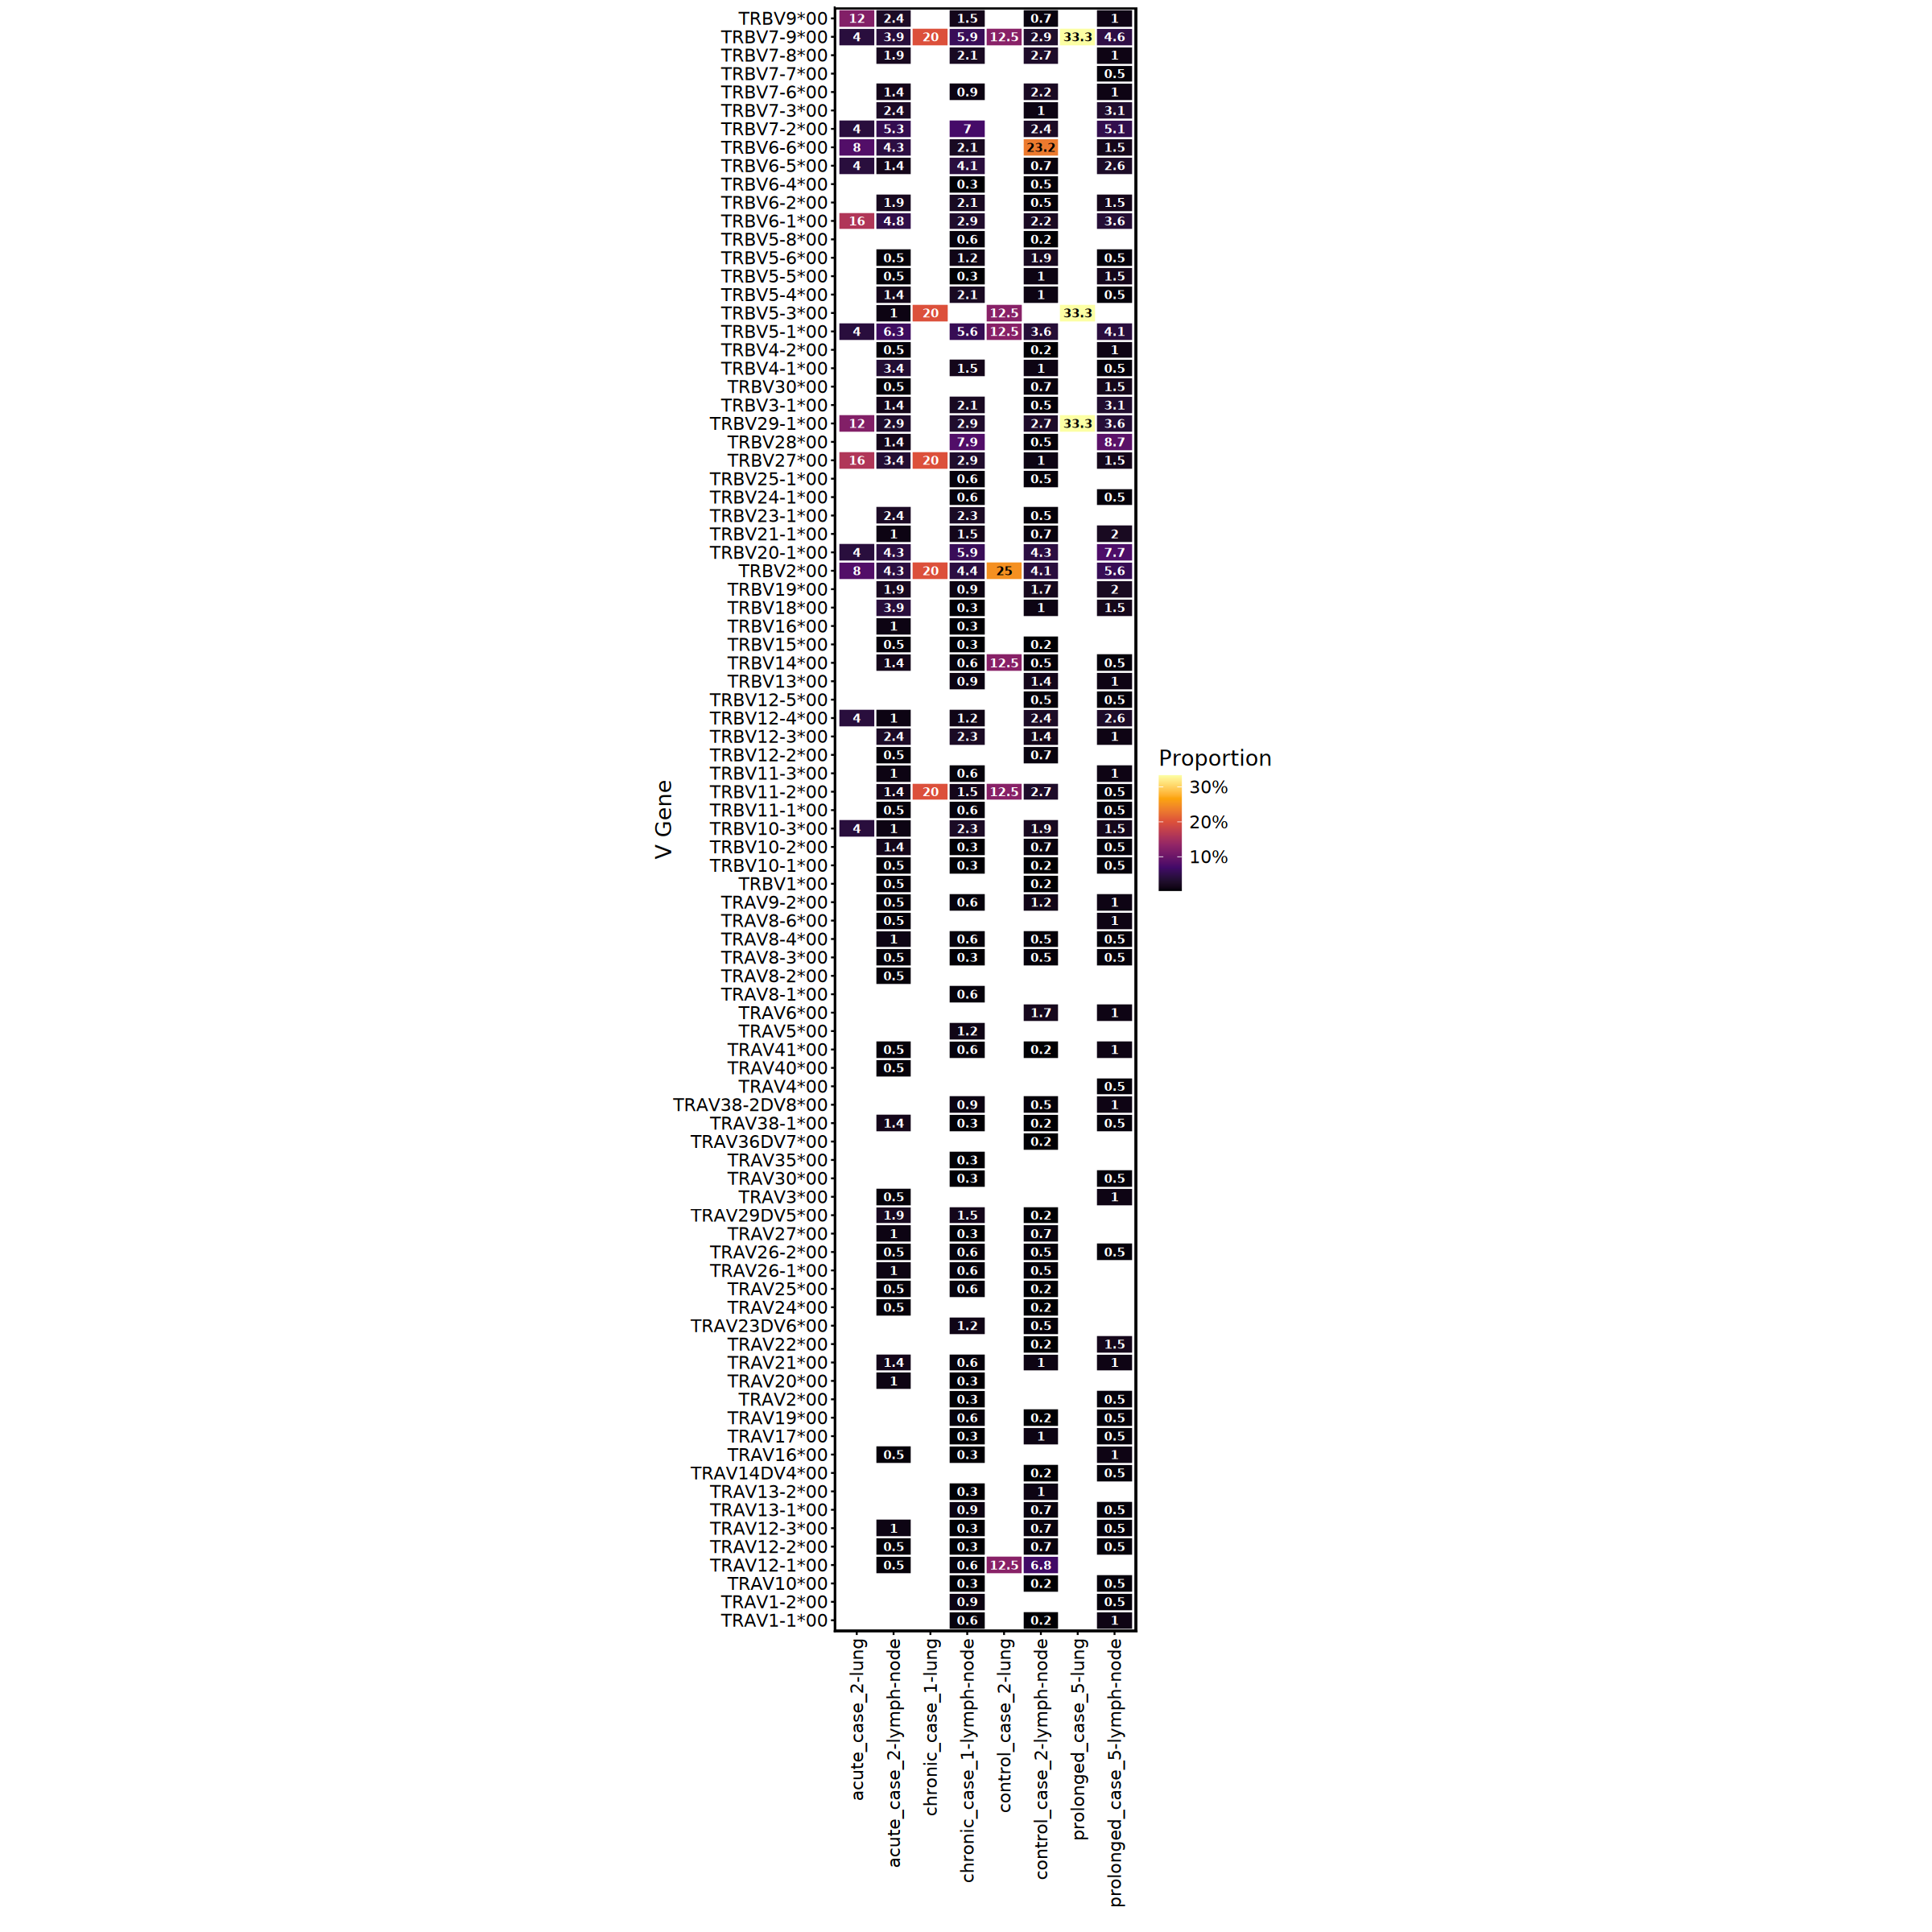

In [14]:
options(repr.plot.width = 20, repr.plot.height = 20, warn = -1)

tcr_gene %>%
  group_by(cond_tissue, v_gene) %>%
  summarise(count = n(), .groups = "drop") %>%
  group_by(cond_tissue) %>%
  mutate(proportion = count / sum(count)) %>%
  ungroup() %>%
  mutate(text_color = ifelse(proportion > 0.2, "black", "white")) %>%
  ggplot(aes(x = cond_tissue, y = v_gene, fill = proportion)) +
  geom_tile(color = "white", linewidth = 0.5) +
  geom_text(aes(label = round(proportion * 100, 1), color = text_color), 
            fontface = "bold", size = 3) +
  scale_fill_viridis_c(option = "inferno", name = "Proportion",
                       labels = scales::percent_format()) +
  scale_color_identity() +
  labs(x = "", y = "V Gene") +
  theme_classic() +
  theme(text = element_text(size = 16),
        axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5),
        panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
        plot.title = element_text(hjust = 0.5, face = "bold"),
        panel.background = element_rect(fill = "white")) +
  coord_fixed(ratio = 0.5)

Next, we can examine the J gene locus usage across samples examining gene pairings.

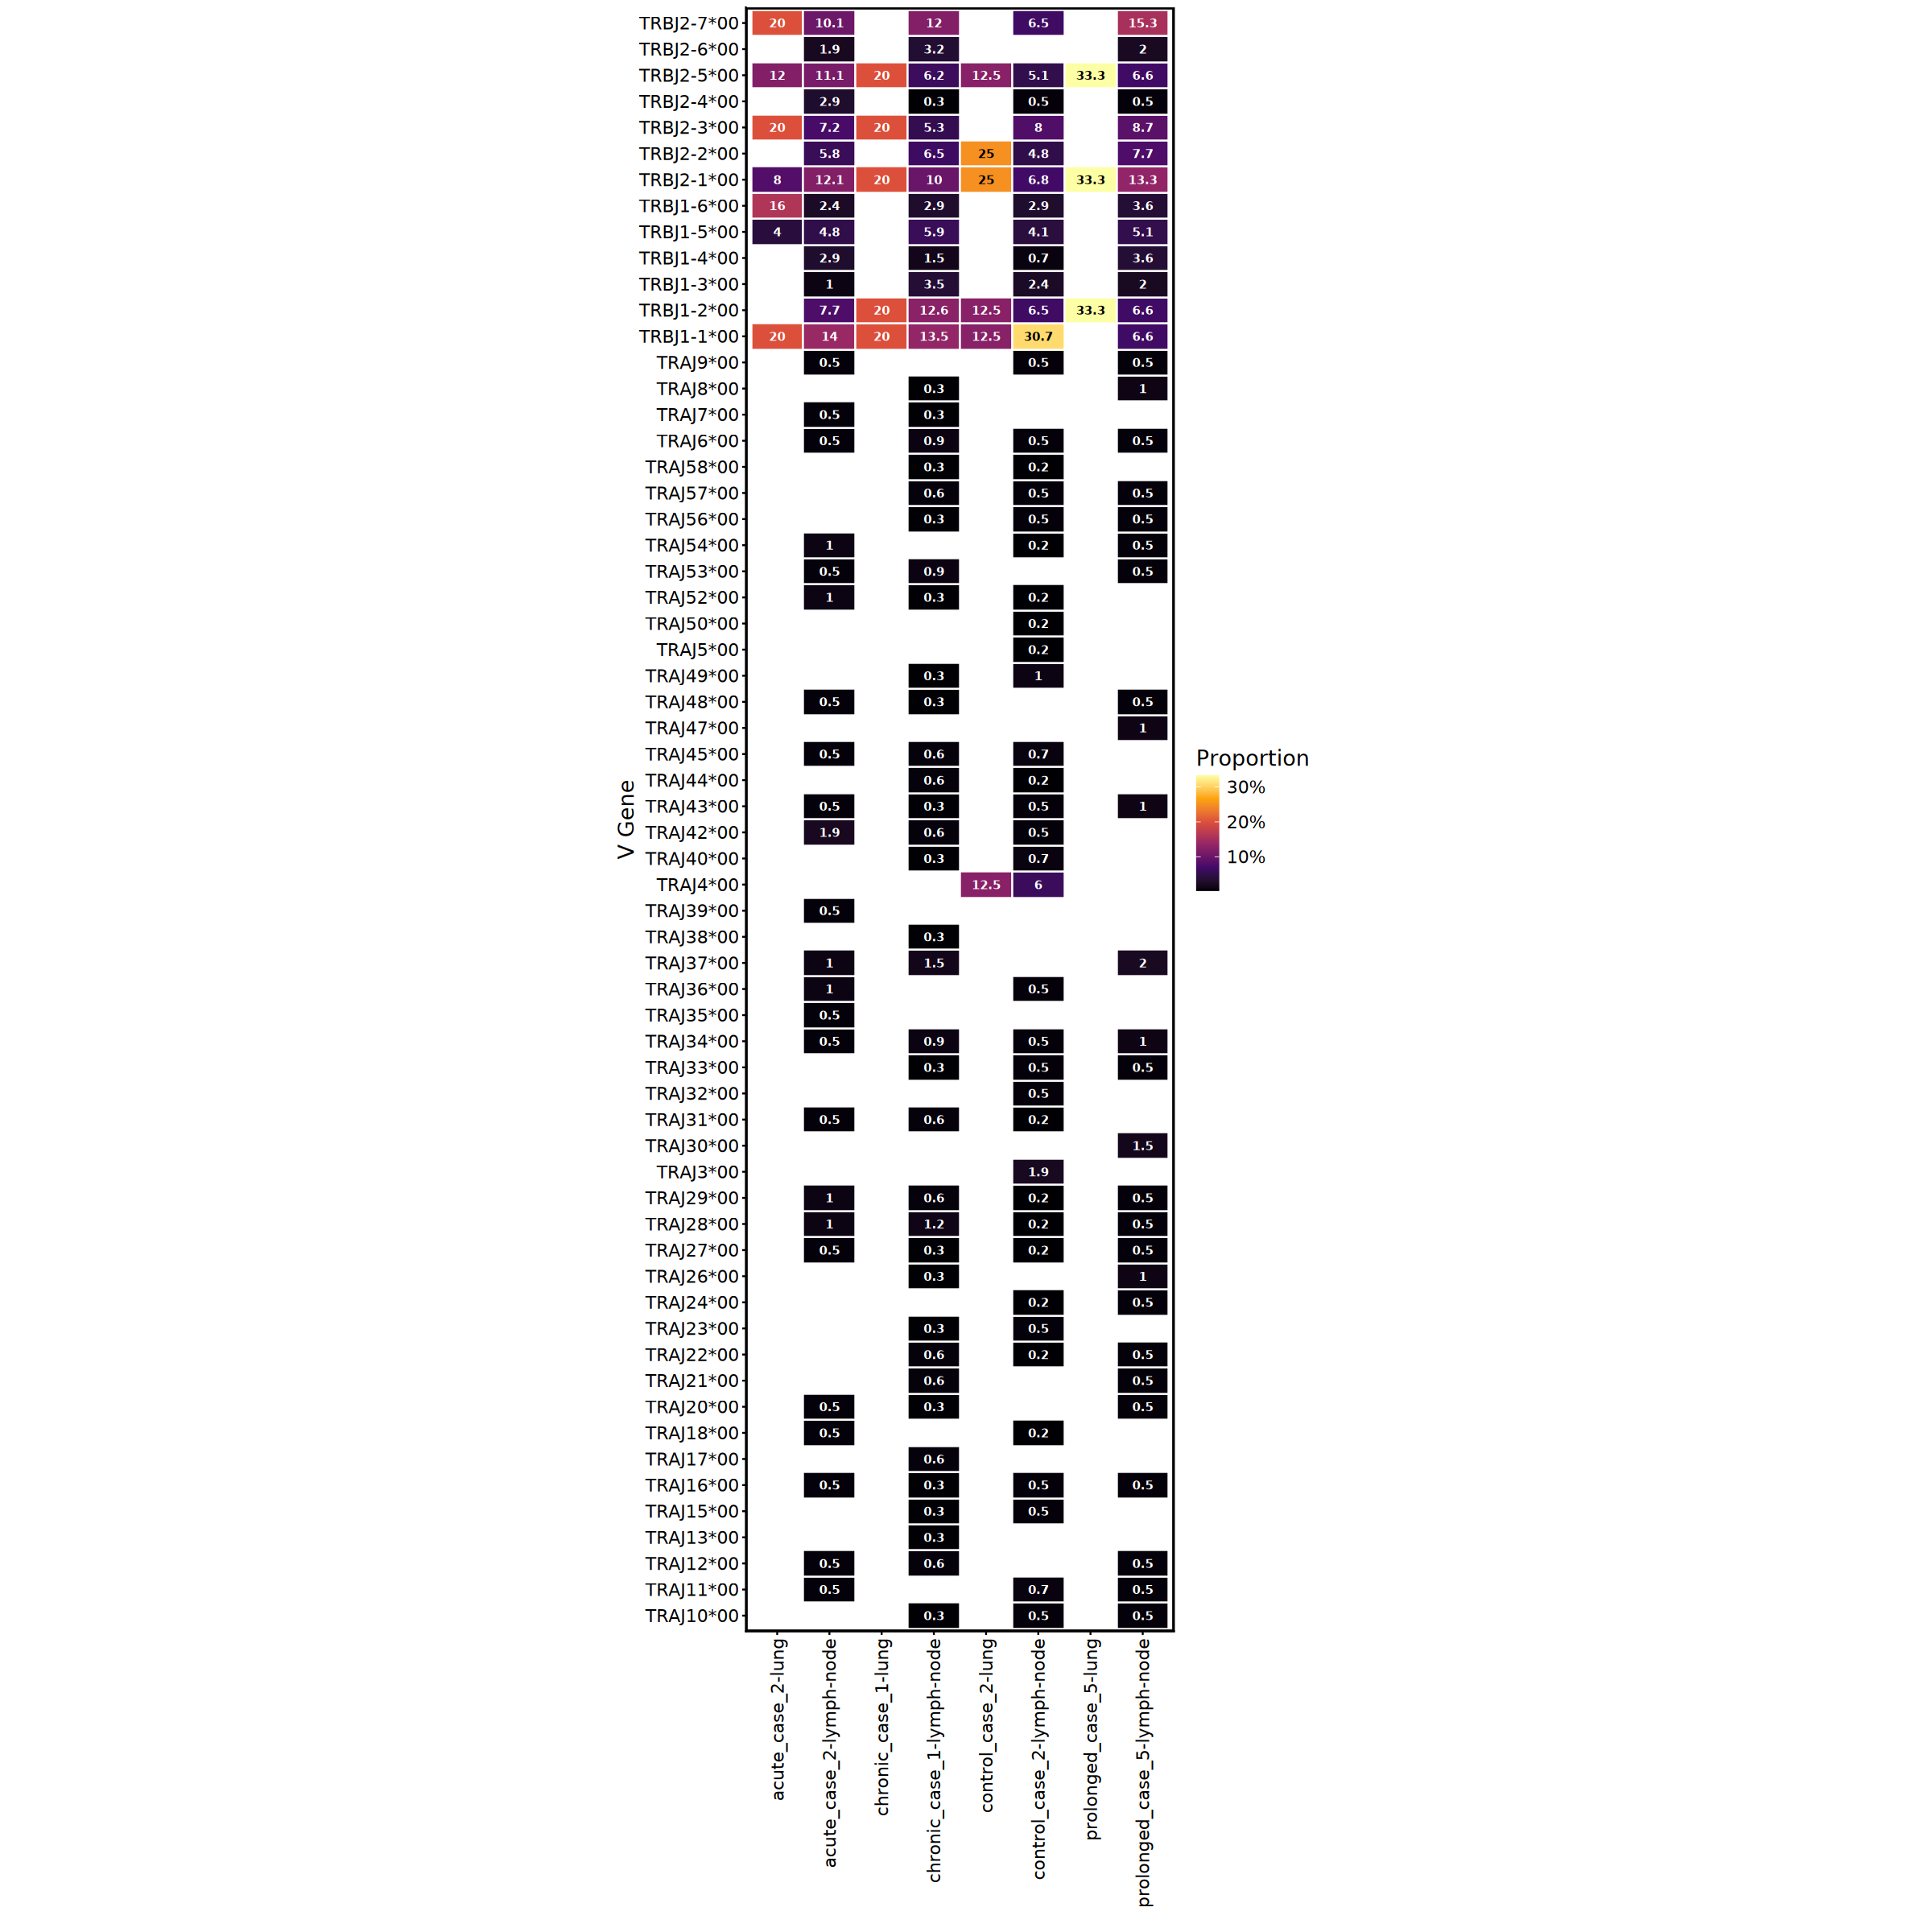

In [15]:
options(repr.plot.width = 20, repr.plot.height = 20, warn = -1)

tcr_gene %>%
  group_by(cond_tissue, j_gene) %>%
  summarise(count = n(), .groups = "drop") %>%
  group_by(cond_tissue) %>%
  mutate(proportion = count / sum(count)) %>%
  ungroup() %>%
  mutate(text_color = ifelse(proportion > 0.2, "black", "white")) %>%
  ggplot(aes(x = cond_tissue, y = j_gene, fill = proportion)) +
  geom_tile(color = "white", linewidth = 0.5) +
  geom_text(aes(label = round(proportion * 100, 1), color = text_color), 
            fontface = "bold", size = 3) +
  scale_fill_viridis_c(option = "inferno", name = "Proportion",
                       labels = scales::percent_format()) +
  scale_color_identity() +
  labs(x = "", y = "V Gene") +
  theme_classic() +
  theme(text = element_text(size = 16),
        axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5),
        panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
        plot.title = element_text(hjust = 0.5, face = "bold"),
        panel.background = element_rect(fill = "white")) +
  coord_fixed(ratio = 0.5)

We can also explore which are the most common V-J gene pairings and how many times are they found.

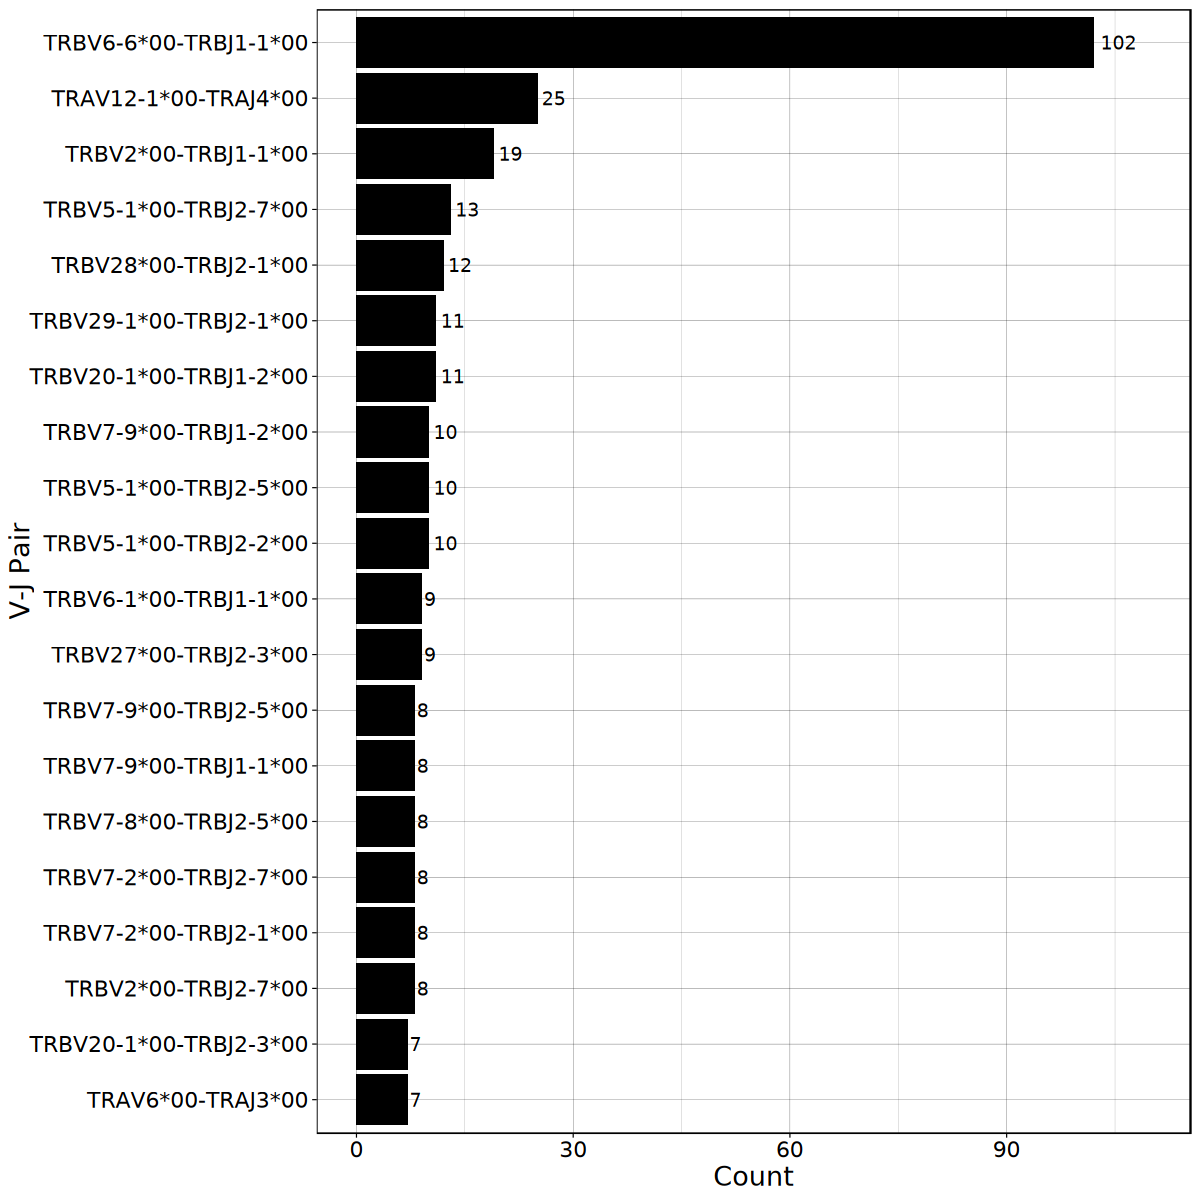

In [16]:
options(repr.plot.width = 10, repr.plot.height = 10, warn = -1)

tcr_gene %>%
    group_by(v_gene, j_gene) %>%
    summarise(count = n(), .groups = "drop") %>%
    arrange(desc(count)) %>%
    slice_head(n = 20) %>%
    mutate(vj_pair = paste(v_gene, j_gene, sep = "-")) %>%
    
    ggplot(aes(x = reorder(vj_pair, count), y = count)) +
    geom_bar(stat = "identity", fill = "black") +
    geom_text(aes(label = count), hjust = -0.2) +
    coord_flip() +
    scale_y_continuous(limits = c(0, 110)) +
    labs(x = "V-J Pair", y = "Count") +
    theme_linedraw() +
    theme(text = element_text(size = 16))

## Clonal dynamics

First, we will check for the exact number of overlapping clones between all samples and the Morisita’s overlap index. Morisita’s overlap index is a frequency-weighted metric that strongly emphasizes abundant clonotypes while being robust to differences in sampling depth. It reflects the probability that two randomly drawn sequences, one from each repertoire, belong to the same clonotype. Morisita’s index is particularly well-suited for comparing biological similarity driven by dominant clonal expansions.

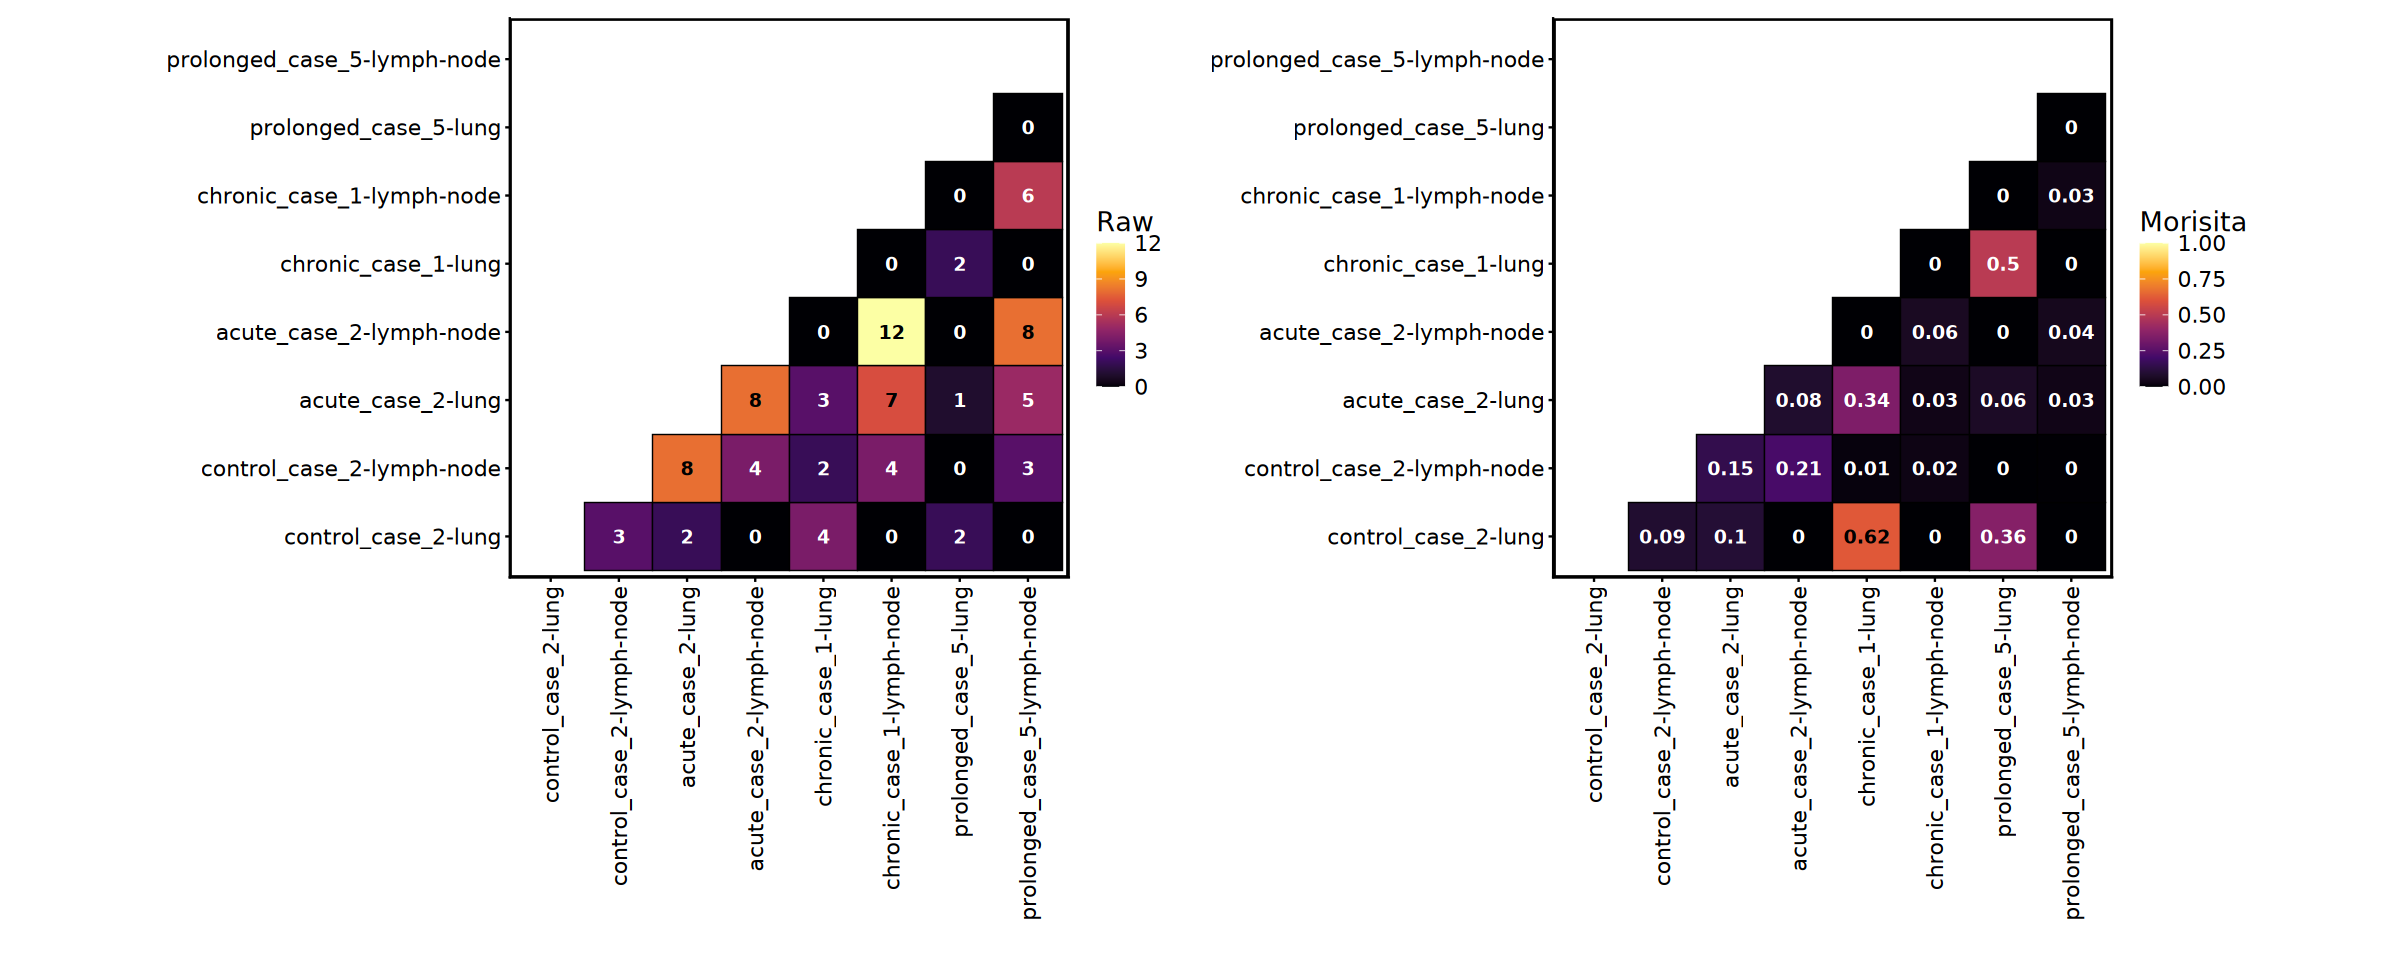

In [17]:
options(repr.plot.width = 20, repr.plot.height = 8, warn = -1)

samples <- unique(tcr_df$cond_tissue)
n_samples <- length(samples)
raw_matrix <- matrix(NA, nrow = n_samples, ncol = n_samples,
                     dimnames = list(samples, samples))

for (i in 1:(n_samples-1)) {
  for (j in (i+1):n_samples) {
    clones_i <- tcr_df %>% filter(cond_tissue == samples[i]) %>% pull(aaSeqCDR3) %>% unique()
    clones_j <- tcr_df %>% filter(cond_tissue == samples[j]) %>% pull(aaSeqCDR3) %>% unique()
    raw_matrix[i, j] <- length(intersect(clones_i, clones_j))
  }
}

morisita_matrix <- matrix(NA, nrow = n_samples, ncol = n_samples,
                          dimnames = list(samples, samples))

for (i in 1:(n_samples-1)) {
  for (j in (i+1):n_samples) {
    freq_i <- tcr_df %>% filter(cond_tissue == samples[i]) %>% 
      group_by(aaSeqCDR3) %>% summarise(count = n(), .groups = "drop")
    freq_j <- tcr_df %>% filter(cond_tissue == samples[j]) %>% 
      group_by(aaSeqCDR3) %>% summarise(count = n(), .groups = "drop")
    
    merged <- full_join(freq_i, freq_j, by = "aaSeqCDR3", suffix = c("_i", "_j"))
    merged[is.na(merged)] <- 0
    
    n_i <- sum(merged$count_i)
    n_j <- sum(merged$count_j)
    
    if (n_i > 0 && n_j > 0) {
      lambda_i <- sum(merged$count_i^2) / (n_i^2)
      lambda_j <- sum(merged$count_j^2) / (n_j^2)
      morisita_matrix[i, j] <- 2 * sum(merged$count_i * merged$count_j) / ((lambda_i + lambda_j) * n_i * n_j)
    }
  }
}

raw_data <- as.data.frame(raw_matrix) %>%
  tibble::rownames_to_column("sample1") %>%
  pivot_longer(cols = -sample1, names_to = "sample2", values_to = "overlap") %>%
  mutate(sample1 = factor(sample1, levels = samples),
         sample2 = factor(sample2, levels = samples)) %>%
  filter(!is.na(overlap)) %>%
  mutate(text_color = ifelse(overlap > max(overlap, na.rm = TRUE) / 2, "black", "white"))
morisita_data <- as.data.frame(morisita_matrix) %>%
  tibble::rownames_to_column("sample1") %>%
  pivot_longer(cols = -sample1, names_to = "sample2", values_to = "overlap") %>%
  mutate(sample1 = factor(sample1, levels = samples),
         sample2 = factor(sample2, levels = samples)) %>%
  filter(!is.na(overlap)) %>%
  mutate(text_color = ifelse(overlap > 0.5, "black", "white"))

p1 <- ggplot(raw_data, aes(x = sample2, y = sample1, fill = overlap)) +
  geom_tile(color = "black", linewidth = 0.3) +
  geom_text(aes(label = round(overlap, 0), color = text_color), fontface = "bold") +
  scale_color_identity() +
  scale_fill_viridis_c(option = "inferno", name = "Raw", direction = 1) +
  scale_x_discrete(drop = FALSE) +
  scale_y_discrete(drop = FALSE) +
  labs(x = "", y = "") +
  theme_classic() +
  theme(text = element_text(size = 16),
        axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5),
        panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
        plot.title = element_text(hjust = 0.5, face = "bold"),
        panel.background = element_rect(fill = "white")) +
  coord_fixed()

p2 <- ggplot(morisita_data, aes(x = sample2, y = sample1, fill = overlap)) +
  geom_tile(color = "black", linewidth = 0.3) +
  geom_text(aes(label = round(overlap, 2), color = text_color), fontface = "bold") +
  scale_color_identity() +
  scale_fill_viridis_c(option = "inferno", name = "Morisita", limits = c(0, 1), direction = 1) +
  scale_x_discrete(drop = FALSE) +
  scale_y_discrete(drop = FALSE) +
  labs(x = "", y = "") +
  theme_classic() +
  theme(text = element_text(size = 16),
        axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5),
        panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
        plot.title = element_text(hjust = 0.5, face = "bold"),
        panel.background = element_rect(fill = "white")) +
  coord_fixed()

p1 | p2

We can also check the overlap of clonotypes by condition.

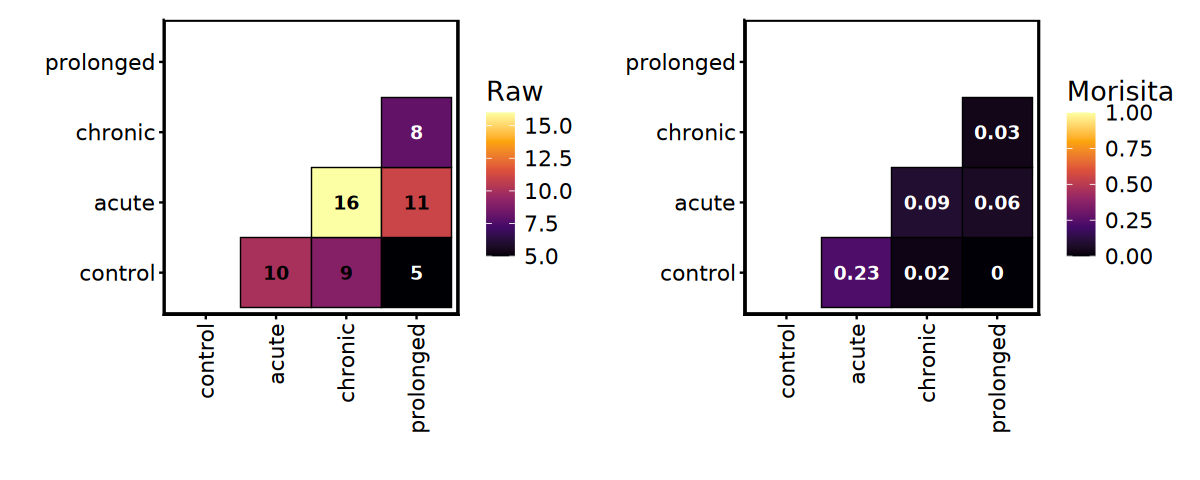

In [18]:
options(repr.plot.width = 10, repr.plot.height = 4, warn = -1)

samples <- unique(tcr_df$condition)
n_samples <- length(samples)

raw_matrix <- matrix(NA, nrow = n_samples, ncol = n_samples,
                     dimnames = list(samples, samples))

for (i in 1:(n_samples-1)) {
  for (j in (i+1):n_samples) {
    clones_i <- tcr_df %>% filter(condition == samples[i]) %>% pull(aaSeqCDR3) %>% unique()
    clones_j <- tcr_df %>% filter(condition == samples[j]) %>% pull(aaSeqCDR3) %>% unique()
    raw_matrix[i, j] <- length(intersect(clones_i, clones_j))
  }
}

morisita_matrix <- matrix(NA, nrow = n_samples, ncol = n_samples,
                          dimnames = list(samples, samples))

for (i in 1:(n_samples-1)) {
  for (j in (i+1):n_samples) {
    freq_i <- tcr_df %>% filter(condition == samples[i]) %>% 
      group_by(aaSeqCDR3) %>% summarise(count = n(), .groups = "drop")
    freq_j <- tcr_df %>% filter(condition == samples[j]) %>% 
      group_by(aaSeqCDR3) %>% summarise(count = n(), .groups = "drop")
    
    merged <- full_join(freq_i, freq_j, by = "aaSeqCDR3", suffix = c("_i", "_j"))
    merged[is.na(merged)] <- 0
    
    n_i <- sum(merged$count_i)
    n_j <- sum(merged$count_j)
    
    if (n_i > 0 && n_j > 0) {
      lambda_i <- sum(merged$count_i^2) / (n_i^2)
      lambda_j <- sum(merged$count_j^2) / (n_j^2)
      morisita_matrix[i, j] <- 2 * sum(merged$count_i * merged$count_j) / ((lambda_i + lambda_j) * n_i * n_j)
    }
  }
}

raw_data <- as.data.frame(raw_matrix) %>%
  tibble::rownames_to_column("sample1") %>%
  pivot_longer(cols = -sample1, names_to = "sample2", values_to = "overlap") %>%
  mutate(sample1 = factor(sample1, levels = samples),
         sample2 = factor(sample2, levels = samples)) %>%
  filter(!is.na(overlap)) %>%
  mutate(text_color = ifelse(overlap > max(overlap, na.rm = TRUE) / 2, "black", "white"))
morisita_data <- as.data.frame(morisita_matrix) %>%
  tibble::rownames_to_column("sample1") %>%
  pivot_longer(cols = -sample1, names_to = "sample2", values_to = "overlap") %>%
  mutate(sample1 = factor(sample1, levels = samples),
         sample2 = factor(sample2, levels = samples)) %>%
  filter(!is.na(overlap)) %>%
  mutate(text_color = ifelse(overlap > 0.5, "black", "white"))

p1 <- ggplot(raw_data, aes(x = sample2, y = sample1, fill = overlap)) +
  geom_tile(color = "black", linewidth = 0.3) +
  geom_text(aes(label = round(overlap, 0), color = text_color), fontface = "bold") +
  scale_color_identity() +
  scale_fill_viridis_c(option = "inferno", name = "Raw", direction = 1) +
  scale_x_discrete(drop = FALSE) +
  scale_y_discrete(drop = FALSE) +
  labs(x = "", y = "") +
  theme_classic() +
  theme(text = element_text(size = 16),
        axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5),
        panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
        plot.title = element_text(hjust = 0.5, face = "bold"),
        panel.background = element_rect(fill = "white")) +
  coord_fixed()

p2 <- ggplot(morisita_data, aes(x = sample2, y = sample1, fill = overlap)) +
  geom_tile(color = "black", linewidth = 0.3) +
  geom_text(aes(label = round(overlap, 2), color = text_color), fontface = "bold") +
  scale_color_identity() +
  scale_fill_viridis_c(option = "inferno", name = "Morisita", limits = c(0, 1), direction = 1) +
  scale_x_discrete(drop = FALSE) +
  scale_y_discrete(drop = FALSE) +
  labs(x = "", y = "") +
  theme_classic() +
  theme(text = element_text(size = 16),
        axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5),
        panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
        plot.title = element_text(hjust = 0.5, face = "bold"),
        panel.background = element_rect(fill = "white")) +
  coord_fixed()

p1 | p2

we can track these shared clones proportions changes between tissues from the same patient. We can also look at general changes in clones dynamics across disease stage, by tracking how the proportions of top clones change between the ordered conditions.

First we will focus in clones shared across tissues.

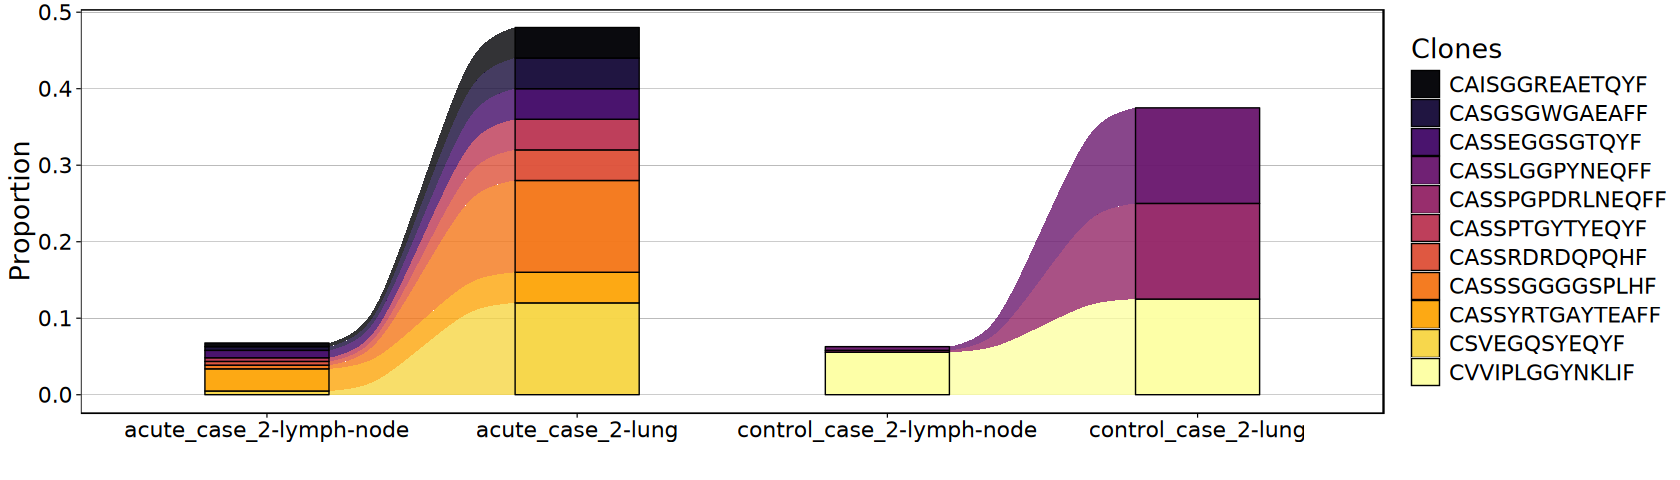

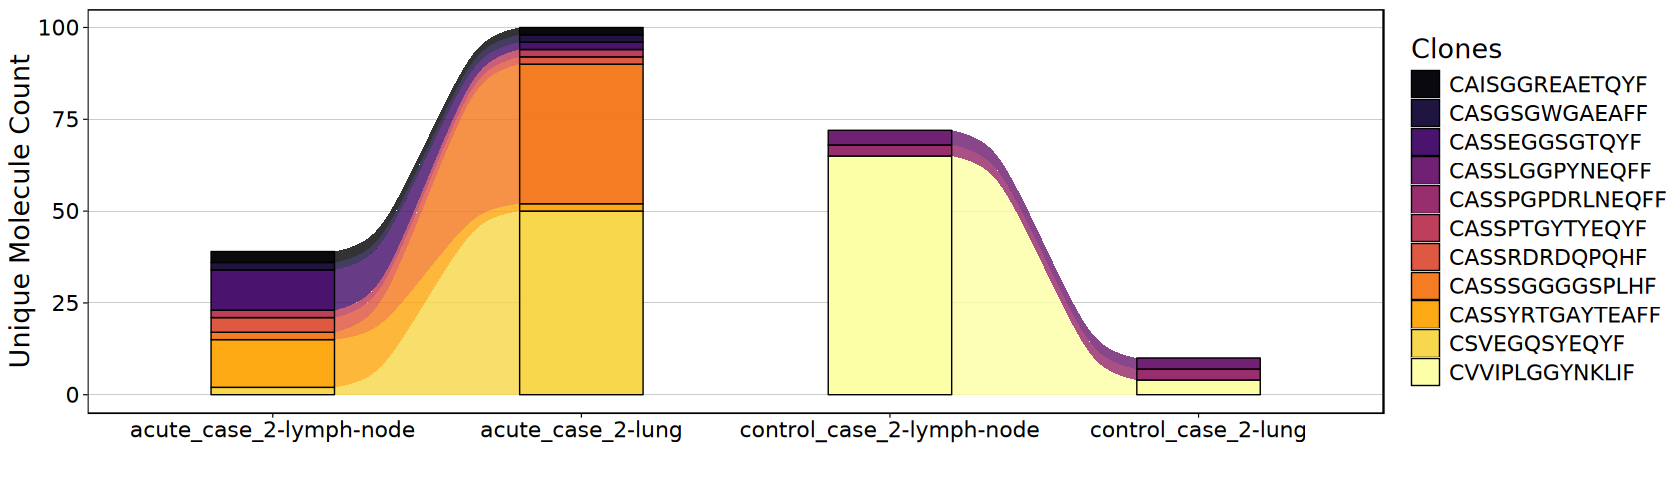

In [19]:
options(repr.plot.width = 14, repr.plot.height = 4, warn = -1)

tcr_df %>%
    group_by(condition, aaSeqCDR3) %>%
    mutate(n_tissues = n_distinct(tissue)) %>%
    ungroup() %>%
    filter(n_tissues > 1) %>%
    group_by(cond_tissue, aaSeqCDR3) %>%
    summarise(count = n(), .groups = "drop") %>%
    left_join(tcr_df %>% 
              group_by(cond_tissue) %>% 
              summarise(total = n(), .groups = "drop"),
              by = "cond_tissue") %>%
    mutate(value = count / total) %>%
    select(-count, -total) %>%
    mutate(condition = sub("_.*", "", cond_tissue),
           tissue = sub(".*_", "", cond_tissue)) %>%
    mutate(cond_tissue = factor(cond_tissue, levels = c("acute_case_2-lymph-node", "acute_case_2-lung", "control_case_2-lymph-node" ,"control_case_2-lung"))) %>%
    
    ggplot(aes(x = cond_tissue, y = value, stratum = aaSeqCDR3,  alluvium = aaSeqCDR3, fill = aaSeqCDR3)) +
    geom_alluvium(alpha = 0.8, width = 0.4) +
    geom_stratum(alpha = 0.8, color = "black", linewidth = 0.3, width = 0.4) +
    scale_fill_viridis_d(option = "inferno", name = "Clones") +
    labs(x = "", y = "Proportion") +
    theme_linedraw() +
    theme(text = element_text(size = 16),
          axis.text.x = element_text(hjust = 0.5),
          plot.title = element_text(hjust = 0.5, face = "bold"),
          panel.grid.major.x = element_blank(),
          panel.grid.minor = element_blank(),
          legend.position = "right")

###

tcr_df %>%
    group_by(condition, aaSeqCDR3) %>%
    mutate(n_tissues = n_distinct(tissue)) %>%
    ungroup() %>%
    filter(n_tissues > 1) %>%
    group_by(cond_tissue, aaSeqCDR3) %>%
    summarise(value = sum(uniqueMoleculeCount), .groups = "drop") %>%
    mutate(condition = sub("_.*", "", cond_tissue),
           tissue = sub(".*_", "", cond_tissue)) %>%
    mutate(cond_tissue = factor(cond_tissue, levels = c("acute_case_2-lymph-node", "acute_case_2-lung", "control_case_2-lymph-node", "control_case_2-lung"))) %>%
    
    ggplot(aes(x = cond_tissue, y = value, stratum = aaSeqCDR3, alluvium = aaSeqCDR3, fill = aaSeqCDR3)) +
    geom_alluvium(alpha = 0.8, width = 0.4) +
    geom_stratum(alpha = 0.8, color = "black", linewidth = 0.3, width = 0.4) +
    scale_fill_viridis_d(option = "inferno", name = "Clones") +
    labs(x = "", y = "Unique Molecule Count") +
    theme_linedraw() +
    theme(text = element_text(size = 16),
          axis.text.x = element_text(hjust = 0.5),
          plot.title = element_text(hjust = 0.5, face = "bold"),
          panel.grid.major.x = element_blank(),
          panel.grid.minor = element_blank(),
          legend.position = "right")

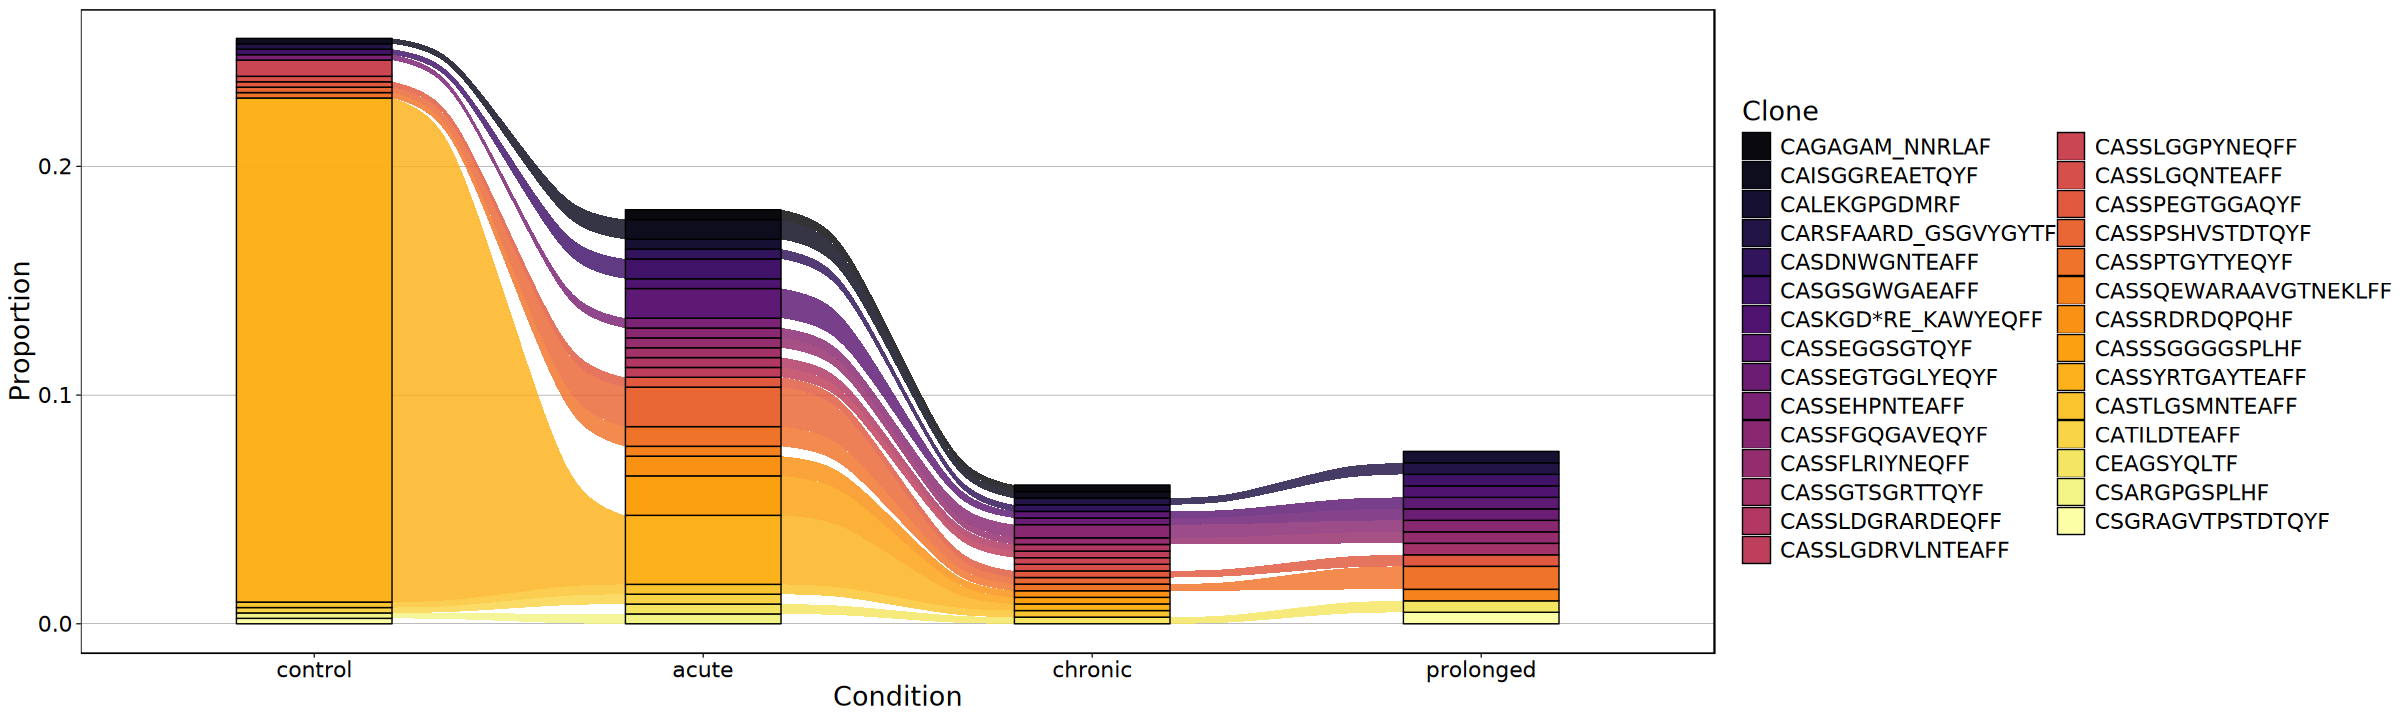

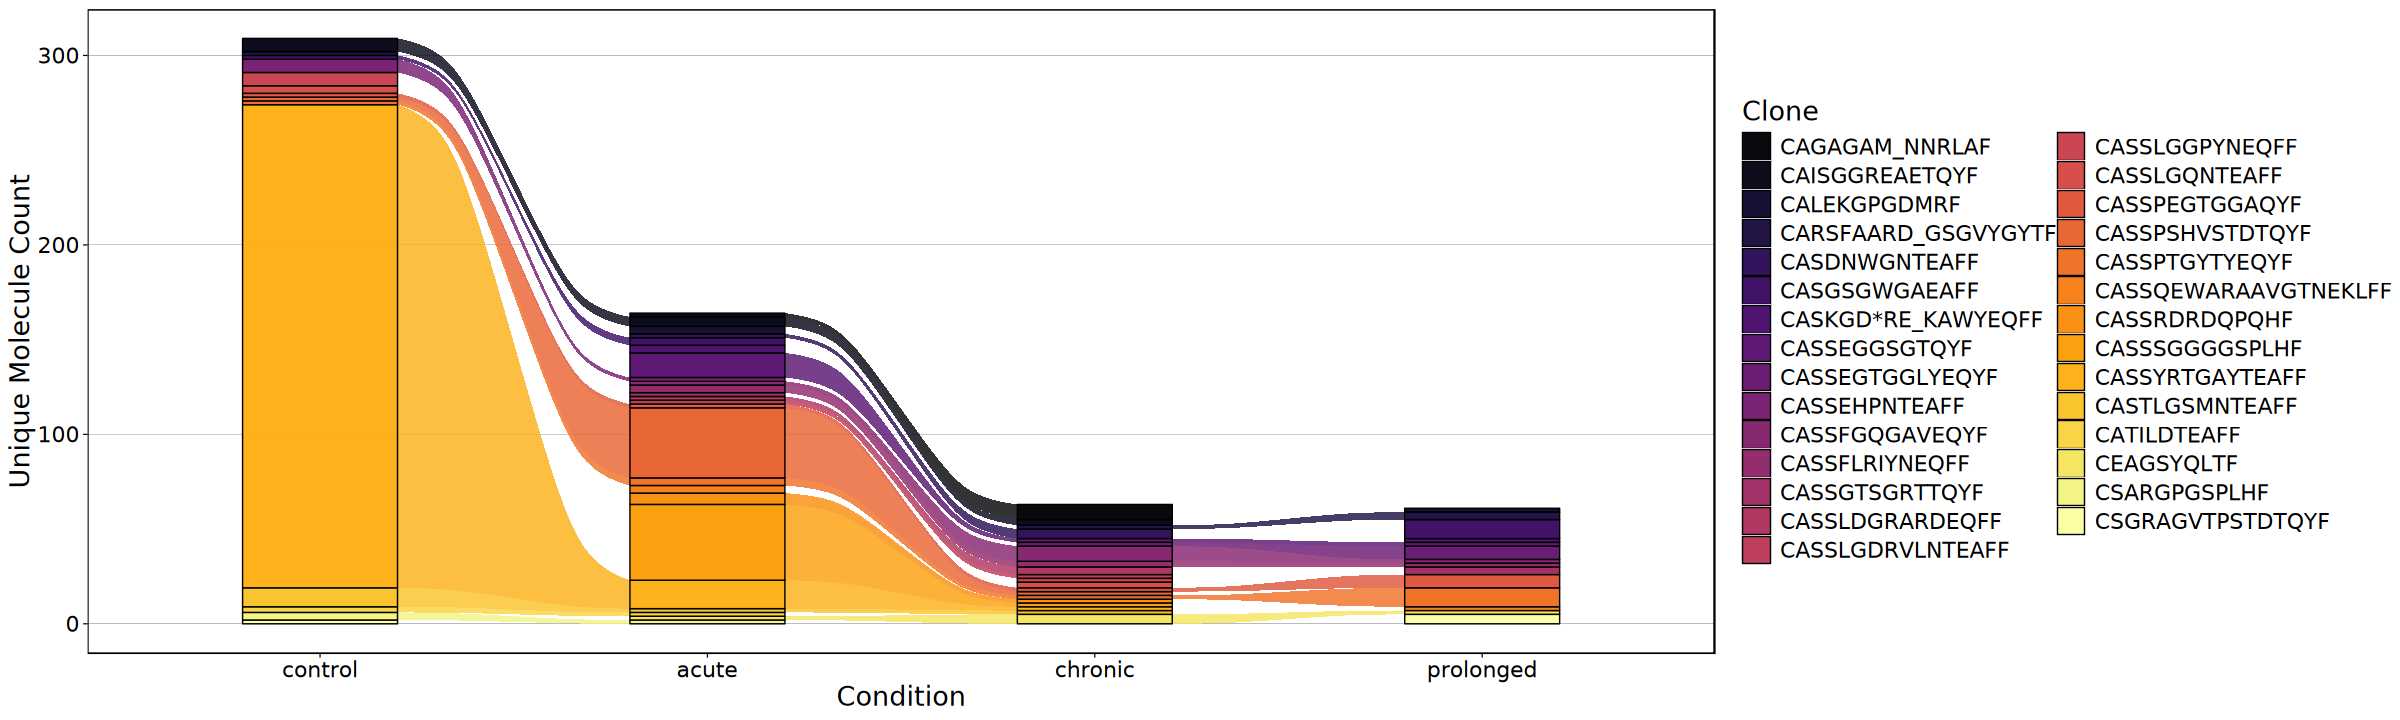

In [20]:
options(repr.plot.width = 20, repr.plot.height = 6, warn = -1)

tcr_df %>%
    group_by(aaSeqCDR3) %>%
    mutate(n_conditions = n_distinct(condition)) %>%
    ungroup() %>%
    filter(n_conditions > 1) %>%
    group_by(condition, aaSeqCDR3) %>%
    summarise(count = n(), .groups = "drop") %>%
    left_join(tcr_df %>% 
              group_by(condition) %>% 
              summarise(total = n(), .groups = "drop"),
              by = "condition") %>%
    mutate(value = count / total) %>%
    select(-count, -total) %>%
    mutate(condition = factor(condition, levels = c("control", "acute", "chronic", "prolonged"))) %>%

    ggplot(aes(x = condition, y = value, stratum = aaSeqCDR3, alluvium = aaSeqCDR3, fill = aaSeqCDR3)) +
    geom_alluvium(alpha = 0.8, width = 0.4) +
    geom_stratum(alpha = 0.8, color = "black", linewidth = 0.3, width = 0.4) +
    scale_fill_viridis_d(option = "inferno", name = "Clone") +
    labs(x = "Condition", y = "Proportion") +
    theme_linedraw() +
    theme(text = element_text(size = 16),
          axis.text.x = element_text(hjust = 0.5),
          plot.title = element_text(hjust = 0.5, face = "bold"),
          panel.grid.major.x = element_blank(),
          panel.grid.minor = element_blank(),
          legend.position = "right")

###

tcr_df %>%
    group_by(aaSeqCDR3) %>%
    mutate(n_conditions = n_distinct(condition)) %>%
    ungroup() %>%
    filter(n_conditions > 1) %>%
    group_by(condition, aaSeqCDR3) %>%
    summarise(value = sum(uniqueMoleculeCount), .groups = "drop") %>%
    mutate(condition = factor(condition, levels = c("control", "acute", "chronic", "prolonged"))) %>%
  
    ggplot(aes(x = condition, y = value, stratum = aaSeqCDR3, alluvium = aaSeqCDR3, fill = aaSeqCDR3)) +
    geom_alluvium(alpha = 0.8, width = 0.4) +
    geom_stratum(alpha = 0.8, color = "black", linewidth = 0.3, width = 0.4) +
    scale_fill_viridis_d(option = "inferno", name = "Clone") +
    labs(x = "Condition", y = "Unique Molecule Count") +
    theme_linedraw() +
    theme(text = element_text(size = 16),
          axis.text.x = element_text(hjust = 0.5),
          plot.title = element_text(hjust = 0.5, face = "bold"),
          panel.grid.major.x = element_blank(),
          panel.grid.minor = element_blank(),
          legend.position = "right")

## Clonotype frequencies (>2 spots)¶

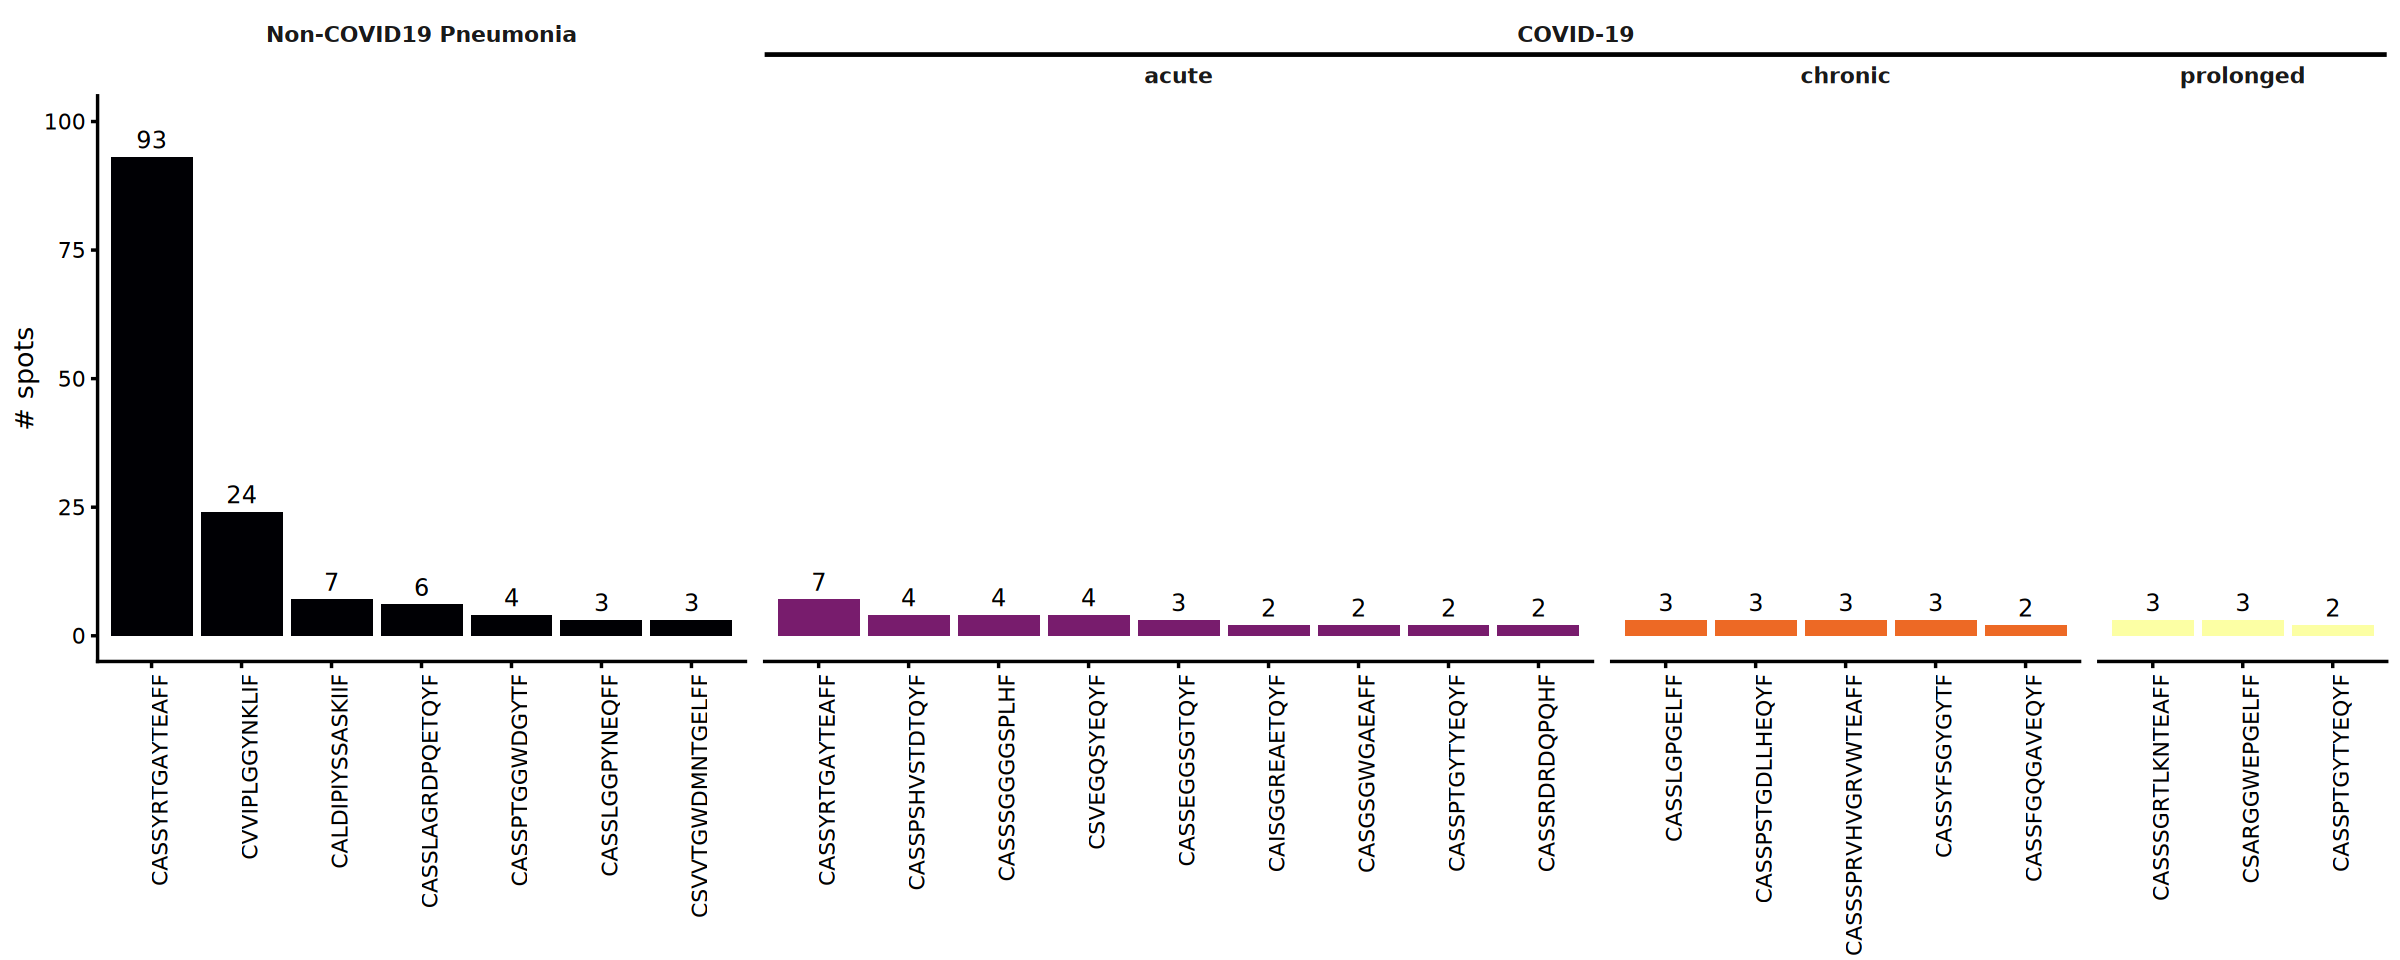

In [21]:
options(repr.plot.width = 20, repr.plot.height = 8, warn = -1)

tcr_df %>%
  filter(!is.na(aaSeqCDR3), !is.na(condition)) %>%
  group_by(aaSeqCDR3) %>%
  mutate(total_spots = n()) %>%
  filter(total_spots > 2) %>%
  group_by(aaSeqCDR3, condition) %>%
  filter(n() >= 2) %>%  
  ungroup() %>%
  group_by(aaSeqCDR3, condition, total_spots) %>%
  summarise(freq = n(), .groups = "drop") %>%
  arrange(condition, desc(total_spots)) %>%
  mutate(condition = factor(condition,
                            levels = c("control", "acute", "chronic", "prolonged")),
         disease_group = ifelse(condition == "control", "Non-COVID19 Pneumonia", "COVID-19"),
         disease_group = factor(disease_group, levels = c("Non-COVID19 Pneumonia", "COVID-19")),
         aaSeqCDR3 = reorder_within(aaSeqCDR3, -freq, condition)) %>%
  
  ggplot(aes(x = aaSeqCDR3, y = freq, fill = condition)) +
  geom_bar(stat = "identity") +
  geom_text(aes(label = freq), vjust = -0.5, size = 5) +
  ggh4x::facet_nested(~ disease_group + condition,
                      scales = "free_x", space = "free_x",
                      labeller = labeller(
                        condition = c("control" = "", "acute" = "acute",
                                    "chronic" = "chronic", "prolonged" = "prolonged"))) +
  coord_cartesian(ylim = c(0, 100)) +
  scale_x_reordered() +
  scale_fill_manual(values = viridis::inferno(4)) +
  labs(y = "# spots", x = NULL) +
  theme_classic(base_size = 16) +
  theme(strip.background = element_blank(),
        strip.text = element_text(face = "bold"),
        ggh4x.facet.nestline = element_line(linewidth = 1),
        legend.position = "none",
        axis.text.x = element_text(angle = 90, hjust = 1),
        panel.spacing = unit(0.8, "lines"))

# Session information

In [22]:
sessionInfo()

R version 4.5.2 (2025-10-31)
Platform: x86_64-conda-linux-gnu
Running under: CentOS Linux 7 (Core)

Matrix products: default
BLAS/LAPACK: /home/groups/singlecell/cvicente/miniconda3/envs/COVID/lib/libopenblasp-r0.3.30.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: Europe/Madrid
tzcode source: system (glibc)

attached base packages:
[1] stats4    stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] viridis_0.6.5       viridisLite_0.4.3   ggh4x_0.3.1        
 [4] ggalluvial_0.12.6   patchwork_1.3.2     Biostrings_2.78.0  
 [7] Seqinfo_1.0.0       XVector_0.50.0      IRanges_2.44.0     
[1